<a href="https://colab.research.google.com/github/alexrmziii/Python_Notebooks/blob/main/ExtraaLearn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ExtraaLearn Project

## Context

The EdTech industry has been surging in the past decade immensely, and according to a forecast, the Online Education market would be worth $286.62bn by 2023 with a compound annual growth rate (CAGR) of 10.26% from 2018 to 2023. The modern era of online education has enforced a lot in its growth and expansion beyond any limit. Due to having many dominant features like ease of information sharing, personalized learning experience, transparency of assessment, etc, it is now preferable to traditional education.

In the present scenario due to the Covid-19, the online education sector has witnessed rapid growth and is attracting a lot of new customers. Due to this rapid growth, many new companies have emerged in this industry. With the availability and ease of use of digital marketing resources, companies can reach out to a wider audience with their offerings. The customers who show interest in these offerings are termed as leads. There are various sources of obtaining leads for Edtech companies, like

* The customer interacts with the marketing front on social media or other online platforms.
* The customer browses the website/app and downloads the brochure
* The customer connects through emails for more information.

The company then nurtures these leads and tries to convert them to paid customers. For this, the representative from the organization connects with the lead on call or through email to share further details.

## Objective

ExtraaLearn is an initial stage startup that offers programs on cutting-edge technologies to students and professionals to help them upskill/reskill. With a large number of leads being generated on a regular basis, one of the issues faced by ExtraaLearn is to identify which of the leads are more likely to convert so that they can allocate resources accordingly. You, as a data scientist at ExtraaLearn, have been provided the leads data to:
* Analyze and build an ML model to help identify which leads are more likely to convert to paid customers,
* Find the factors driving the lead conversion process
* Create a profile of the leads which are likely to convert


## Data Description

The data contains the different attributes of leads and their interaction details with ExtraaLearn. The detailed data dictionary is given below.


**Data Dictionary**
* ID: ID of the lead
* age: Age of the lead
* current_occupation: Current occupation of the lead. Values include 'Professional','Unemployed',and 'Student'
* first_interaction: How did the lead first interacted with ExtraaLearn. Values include 'Website', 'Mobile App'
* profile_completed: What percentage of profile has been filled by the lead on the website/mobile app. Values include Low - (0-50%), Medium - (50-75%), High (75-100%)
* website_visits: How many times has a lead visited the website
* time_spent_on_website: Total time spent on the website
* page_views_per_visit: Average number of pages on the website viewed during the visits.
* last_activity: Last interaction between the lead and ExtraaLearn.
    * Email Activity: Seeking for details about program through email, Representative shared information with lead like brochure of program , etc
    * Phone Activity: Had a Phone Conversation with representative, Had conversation over SMS with representative, etc
    * Website Activity: Interacted on live chat with representative, Updated profile on website, etc

* print_media_type1: Flag indicating whether the lead had seen the ad of ExtraaLearn in the Newspaper.
* print_media_type2: Flag indicating whether the lead had seen the ad of ExtraaLearn in the Magazine.
* digital_media: Flag indicating whether the lead had seen the ad of ExtraaLearn on the digital platforms.
* educational_channels: Flag indicating whether the lead had heard about ExtraaLearn in the education channels like online forums, discussion threads, educational websites, etc.
* referral: Flag indicating whether the lead had heard about ExtraaLearn through reference.
* status: Flag indicating whether the lead was converted to a paid customer or not.

## Importing Necessary Libraries and Data

In [ ]:
!pip install pandas==2.0.3 numpy==1.25.2 matplotlib==3.7.1 seaborn==0.13.1 scikit-learn==1.2.2 statsmodels==0.14.2 --q --user

In [ ]:
# libraries for data manipulation
import pandas as pd
import numpy as np

# libaries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Library to split data
from sklearn.model_selection import train_test_split

# libraries for prediction model
import statsmodels.stats.api as sms
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
from statsmodels.tools.tools import add_constant
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.model_selection import GridSearchCV


# libraries for metric scores
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    roc_auc_score,
    precision_recall_curve,
    roc_curve,
    make_scorer,
)

# sets row limit
pd.set_option("display.max_rows", 200)
# removes column limit
pd.set_option("display.max_columns", None)
# sets floating numbers to 5 decimal points
pd.set_option("display.float_format", lambda x: "%.5f" % x)

# removes warnings
import warnings
warnings.filterwarnings("ignore")
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.simplefilter("ignore", ConvergenceWarning)

## Loading the Dataset

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
data = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Datasets/ExtraaLearn.csv")
df = data.copy()

## Data Overview

- Observations
- Sanity checks

In [ ]:
# displays first 5 rows in the dataset
df.head()

,ID,age,current_occupation,first_interaction,profile_completed,website_visits,time_spent_on_website,page_views_per_visit,last_activity,print_media_type1,print_media_type2,digital_media,educational_channels,referral,status
0,EXT001,57,Unemployed,Website,High,7,1639,1.86100,Website Activity,Yes,No,Yes,No,No,1
1,EXT002,56,Professional,Mobile App,Medium,2,83,0.32000,Website Activity,No,No,No,Yes,No,0
2,EXT003,52,Professional,Website,Medium,3,330,0.07400,Website Activity,No,No,Yes,No,No,0
3,EXT004,53,Unemployed,Website,High,4,464,2.05700,Website Activity,No,No,No,No,No,1
4,EXT005,23,Student,Website,High,4,600,16.91400,Email Activity,No,No,No,No,No,0


In [ ]:
# displays last 5 rows in the dataset
df.tail()

,ID,age,current_occupation,first_interaction,profile_completed,website_visits,time_spent_on_website,page_views_per_visit,last_activity,print_media_type1,print_media_type2,digital_media,educational_channels,referral,status
4607,EXT4608,35,Unemployed,Mobile App,Medium,15,360,2.17000,Phone Activity,No,No,No,Yes,No,0
4608,EXT4609,55,Professional,Mobile App,Medium,8,2327,5.39300,Email Activity,No,No,No,No,No,0
4609,EXT4610,58,Professional,Website,High,2,212,2.69200,Email Activity,No,No,No,No,No,1
4610,EXT4611,57,Professional,Mobile App,Medium,1,154,3.87900,Website Activity,Yes,No,No,No,No,0
4611,EXT4612,55,Professional,Website,Medium,4,2290,2.07500,Phone Activity,No,No,No,No,No,0


In [ ]:
# displays dataframe size
df.shape

(4612, 15)

In [ ]:
# displays datatypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4612 entries, 0 to 4611
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     4612 non-null   object 
 1   age                    4612 non-null   int64  
 2   current_occupation     4612 non-null   object 
 3   first_interaction      4612 non-null   object 
 4   profile_completed      4612 non-null   object 
 5   website_visits         4612 non-null   int64  
 6   time_spent_on_website  4612 non-null   int64  
 7   page_views_per_visit   4612 non-null   float64
 8   last_activity          4612 non-null   object 
 9   print_media_type1      4612 non-null   object 
 10  print_media_type2      4612 non-null   object 
 11  digital_media          4612 non-null   object 
 12  educational_channels   4612 non-null   object 
 13  referral               4612 non-null   object 
 14  status                 4612 non-null   int64  
dtypes: f

In [ ]:
# displays statistical summary of the data
df.describe()

,age,website_visits,time_spent_on_website,page_views_per_visit,status
count,4612.00000,4612.00000,4612.00000,4612.00000,4612.00000
mean,46.20121,3.56678,724.01127,3.02613,0.29857
std,13.16145,2.82913,743.82868,1.96812,0.45768
min,18.00000,0.00000,0.00000,0.00000,0.00000
25%,36.00000,2.00000,148.75000,2.07775,0.00000
50%,51.00000,3.00000,376.00000,2.79200,0.00000
75%,57.00000,5.00000,1336.75000,3.75625,1.00000
max,63.00000,30.00000,2537.00000,18.43400,1.00000


In [ ]:
# displays summary of object columns
df.describe(include="object")

,ID,current_occupation,first_interaction,profile_completed,last_activity,print_media_type1,print_media_type2,digital_media,educational_channels,referral
count,4612,4612,4612,4612,4612,4612,4612,4612,4612,4612
unique,4612,3,2,3,3,2,2,2,2,2
top,EXT001,Professional,Website,High,Email Activity,No,No,No,No,No
freq,1,2616,2542,2264,2278,4115,4379,4085,3907,4519


In [ ]:
# drops the unique ID column
df.drop("ID", axis=1, inplace=True)

## Exploratory Data Analysis (EDA)

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

**Questions**
1. Leads will have different expectations from the outcome of the course and the current occupation may play a key role in getting them to participate in the program. Find out how current occupation affects lead status.
2. The company's first impression on the customer must have an impact. Do the first channels of interaction have an impact on the lead status?
3. The company uses multiple modes to interact with prospects. Which way of interaction works best?
4. The company gets leads from various channels such as print media, digital media, referrals, etc. Which of these channels have the highest lead conversion rate?
5. People browsing the website or mobile application are generally required to create a profile by sharing their personal data before they can access additional information.Does having more details about a prospect increase the chances of conversion?

### Custom Functions

In [ ]:
# function for histogram + boxplot
def histogram_boxplot(data, feature, figsize=(15, 10), kde=False, bins=None):
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,
        sharex=True,
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    ) # mean
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # median

In [ ]:
# function for labeled barplots
def labeled_barplot(data, feature, perc=False, n=None):
    total = len(data[feature])  # column length
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 2, 6))
    else:
        plt.figure(figsize=(n + 2, 6))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n],
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # %
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width
        y = p.get_height()  # height

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )

    plt.show()

In [ ]:
# function for stacked barplots
def stacked_barplot(data, predictor, target):
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 5, 5))
    plt.legend(
        loc="lower left", frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

In [ ]:
# function for distributions wrt target
def distribution_plot_wrt_target(data, predictor, target):
    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    target_uniq = data[target].unique()

    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="teal",
        stat="density",
    )

    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="orange",
        stat="density",
    )

    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")

    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        palette="gist_rainbow",
    )

    plt.tight_layout()
    plt.show()

### Univariate Analysis

#### Age

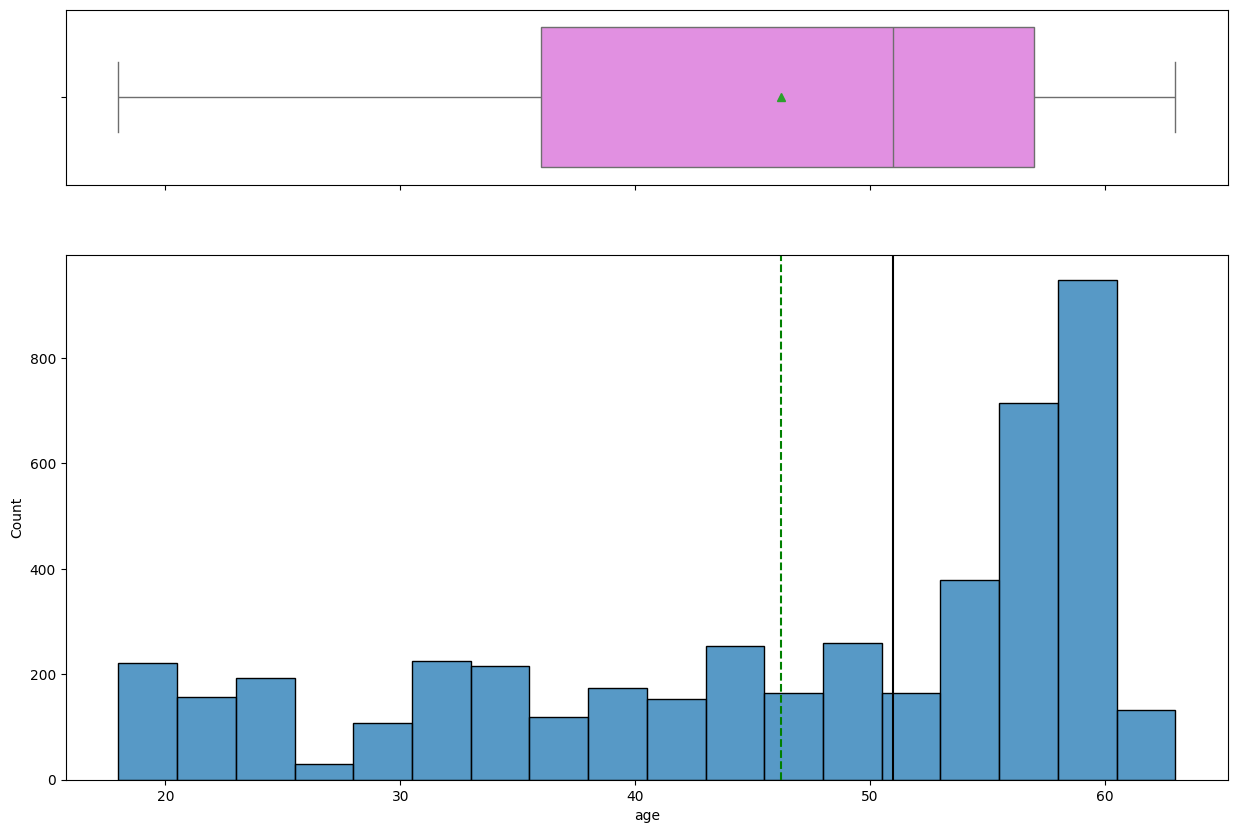

In [ ]:
histogram_boxplot(df, "age")

Observations: The median age of the leads was about 50. Half of the leads fell between the ages of 35 and ~56.

#### Current Occupation

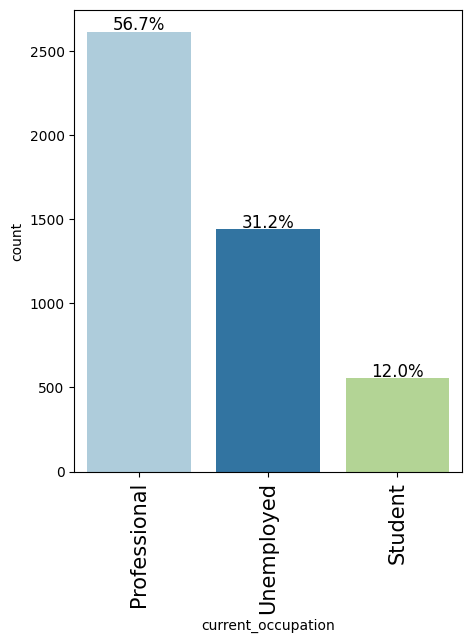

In [ ]:
labeled_barplot(df, "current_occupation", perc=True)

Observations: Most leads held a professional occupation (56.7%). This is followed by unemployed (31.2%) and student (12%) leads.

#### First Interaction

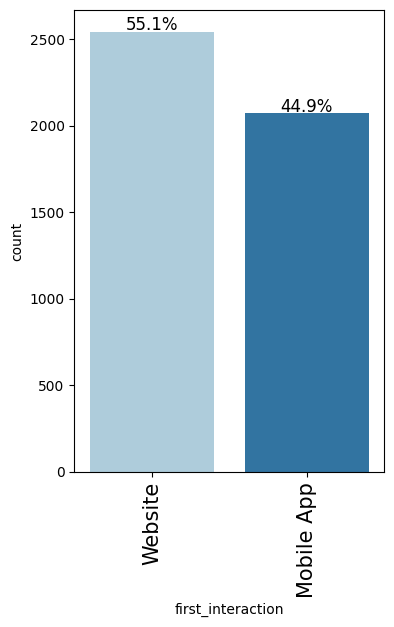

In [ ]:
labeled_barplot(df, "first_interaction", perc=True)

Observations: A greater percent of leads interacted via website than mobile app.

#### Profile Completed

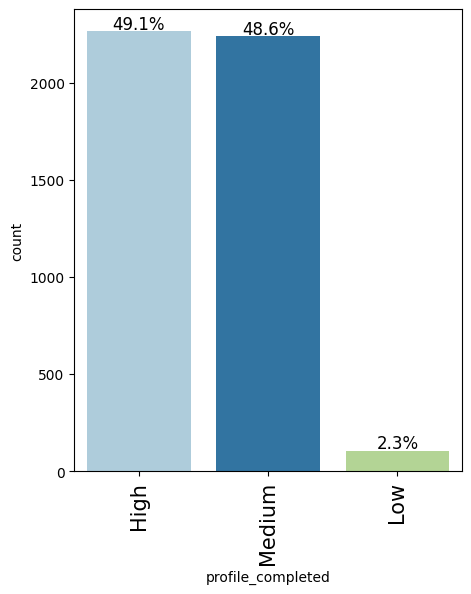

In [ ]:
labeled_barplot(df, "profile_completed", perc=True)

Observations: Almost all of the leads have completed at least 50% of their profiles.

#### Website Visits

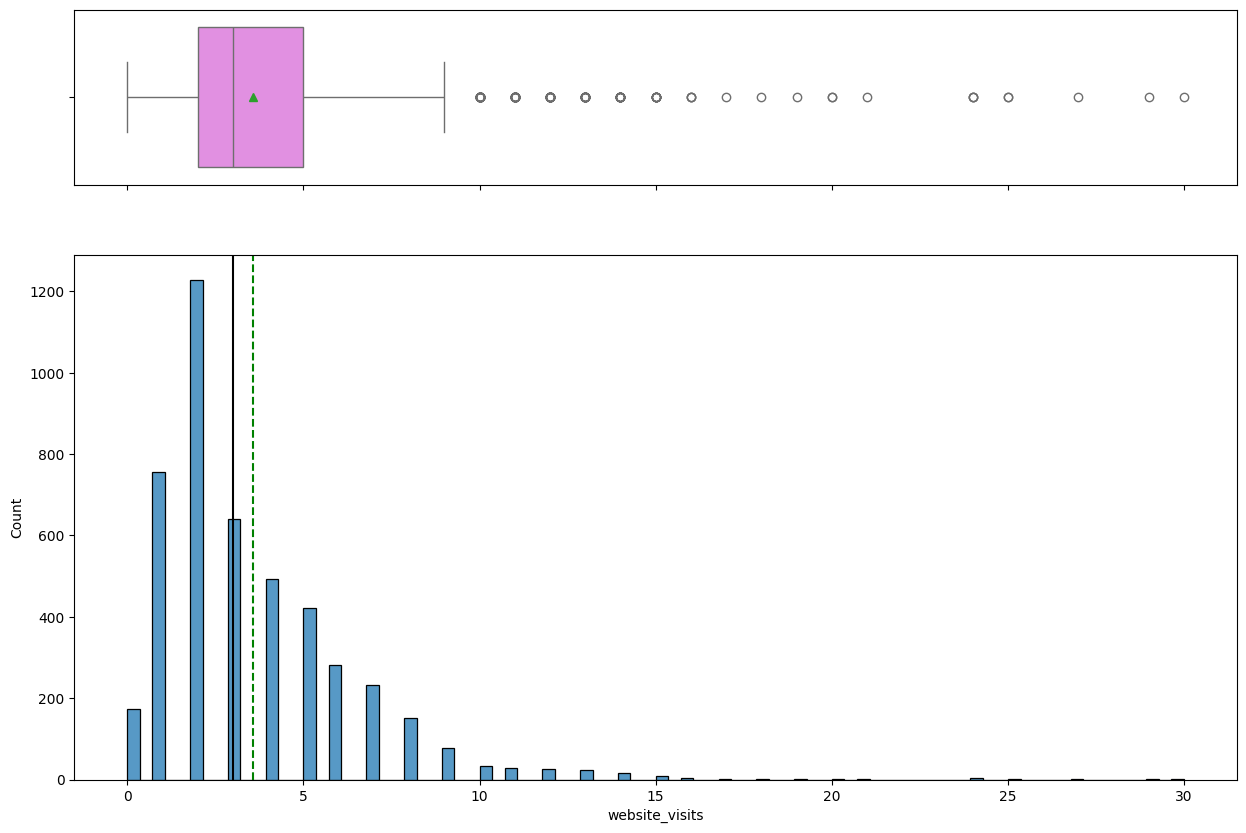

In [ ]:
histogram_boxplot(df, "website_visits")

Observations: The median number of website visits is around 3. Half of the leads visited the website between 2 and 5 times.

#### Time Spent On Website

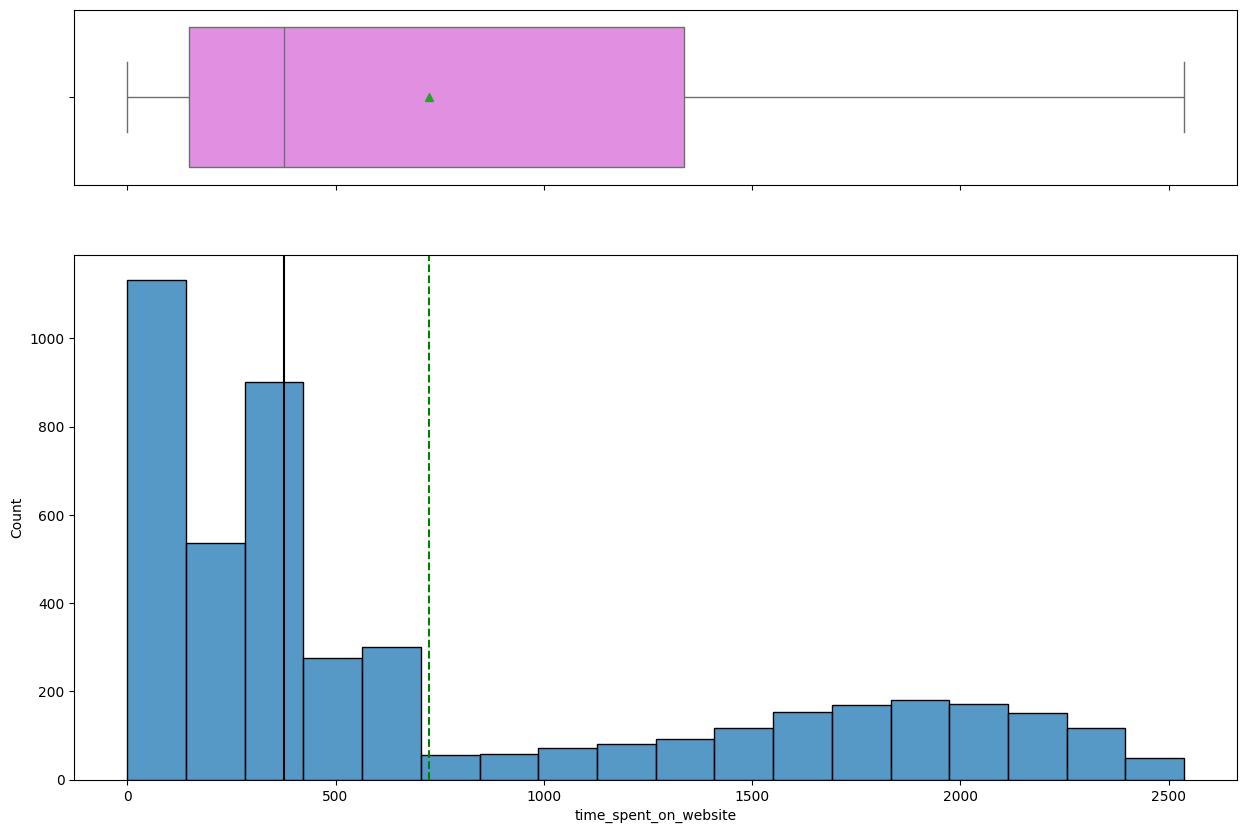

In [ ]:
histogram_boxplot(df, "time_spent_on_website")

Observations: The median time spent on the website is about 400. 50% of leads spent between ~200 and ~1400 on the website.

#### Page Views Per Visit

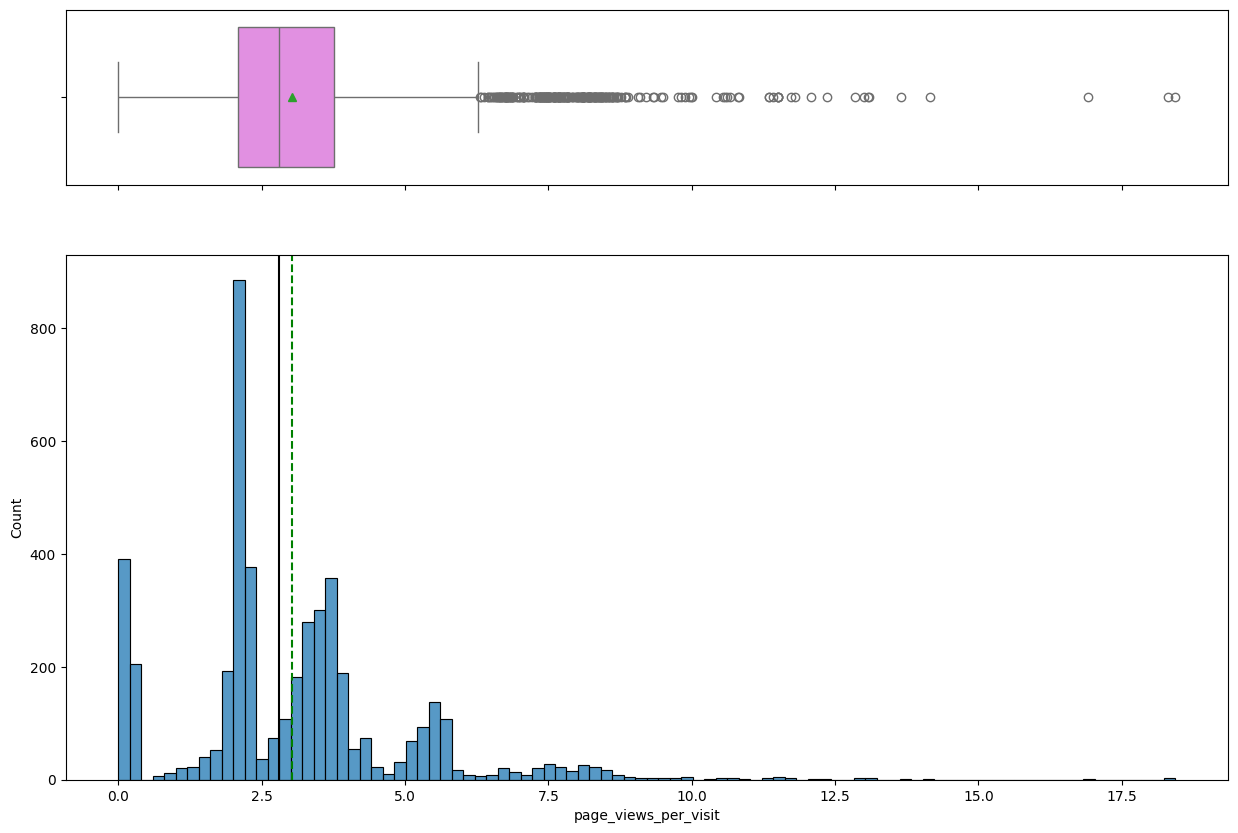

In [ ]:
histogram_boxplot(df, "page_views_per_visit")

Observations: The median number of page views per visit is about 2.75. The mean is ~3.

#### Last Activity

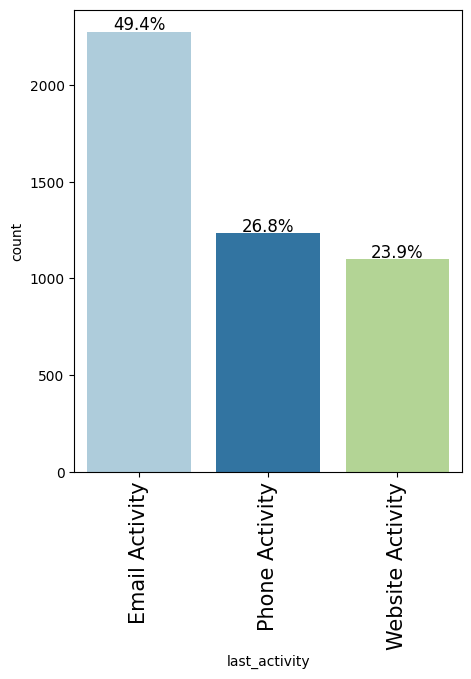

In [ ]:
labeled_barplot(df, "last_activity", perc=True)

Observations: Most interactons were done via email (49.4%). This is followed by phone interactions (26.8%) and website activity (23.9%).

#### Print Media Type 1 (Newspaper)

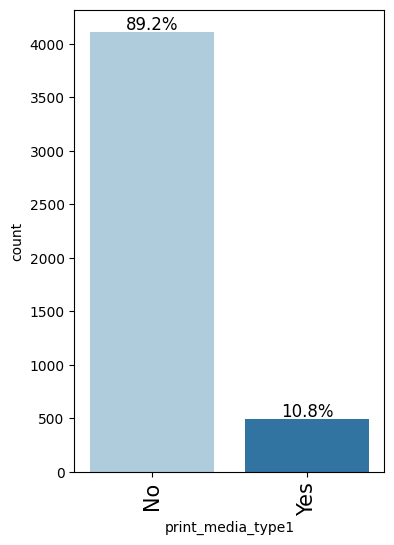

In [ ]:
labeled_barplot(df, "print_media_type1", perc=True)

Observations: The majority of leads (89.2%) had not seen the ExtraaLearn ad in the newspaper.

#### Print Media Type 2 (Magazine)

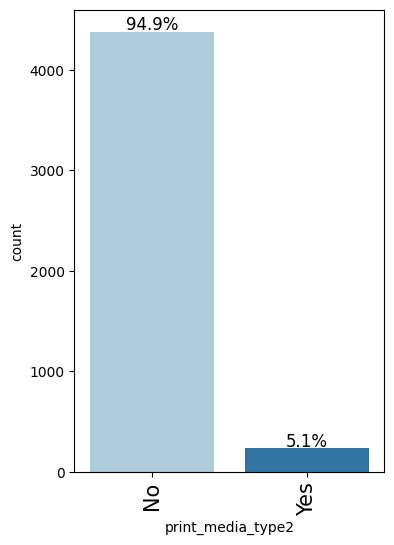

In [ ]:
labeled_barplot(df, "print_media_type2", perc=True)

Observations: A greater majority of leads (94.9%) had not seen the ExtraaLearn ad in the magazine.

#### Digital Media

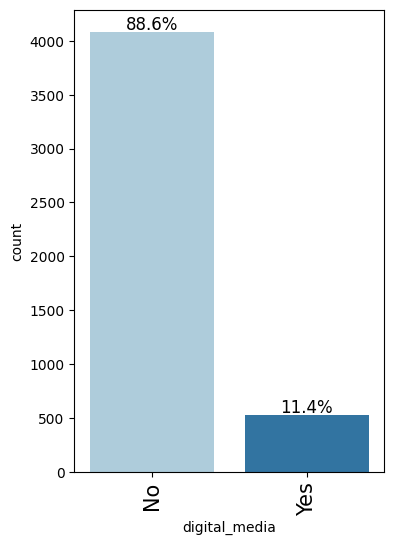

In [ ]:
labeled_barplot(df, "digital_media", perc=True)

Observations: The majority of leads (88.6%) had not seen the ExtraaLearn ad in digital media.

#### Educational Channels

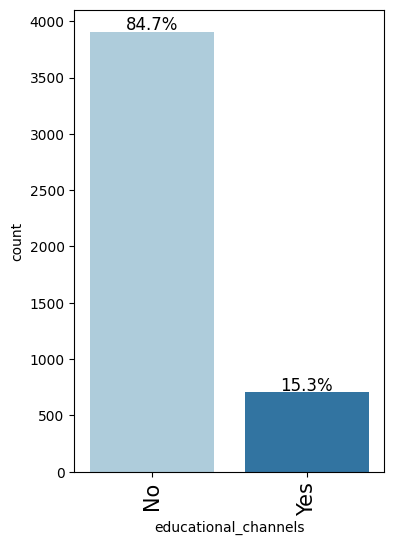

In [ ]:
labeled_barplot(df, "educational_channels", perc=True)

Observations: A lesser majority of leads (84.7%) had not heard about ExtraaLearn in educational channels. Out of all the advertising methods, educational channels appeared to reach the most amount of people.

#### Referral

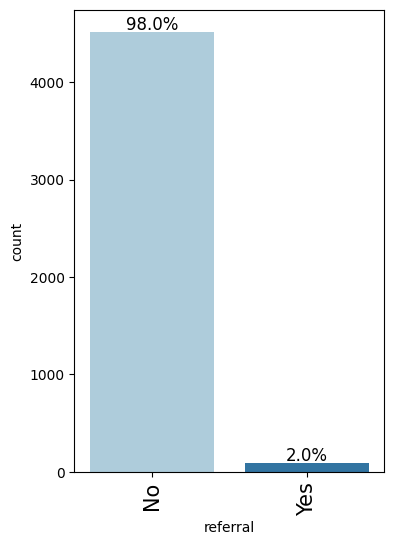

In [ ]:
labeled_barplot(df, "referral", perc=True)

Observations: A vast majority of leads had not heard about ExtraaLearn through reference (98%). Out of the advertising methods, reference appeared to reach the least amount of people.

#### Status

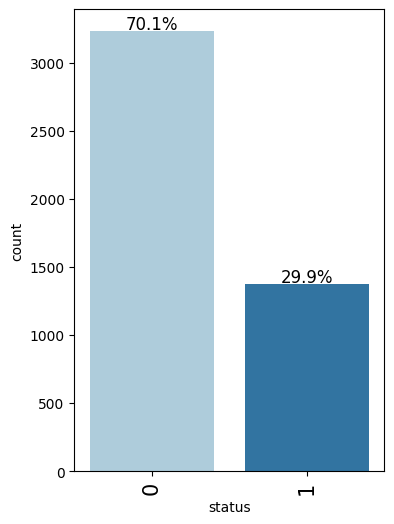

In [ ]:
labeled_barplot(df, "status", perc=True)

### Multivariate Analysis

#### Correlation Heatmap

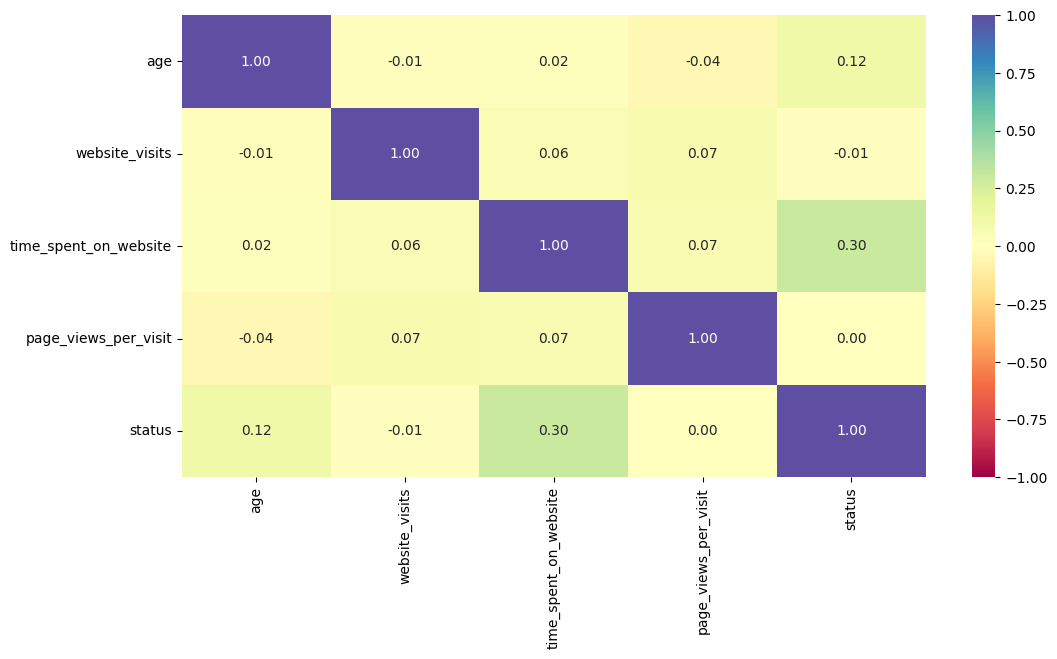

In [ ]:
num_cols = df.select_dtypes(include="number").columns.tolist()
plt.figure(figsize=(12, 6))
sns.heatmap(df[num_cols].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show()

Observations: Time spent on website has the strongest postive correlation with status (0.3). The rest of the variables have little to no relationship with each other.

#### Age vs. Status

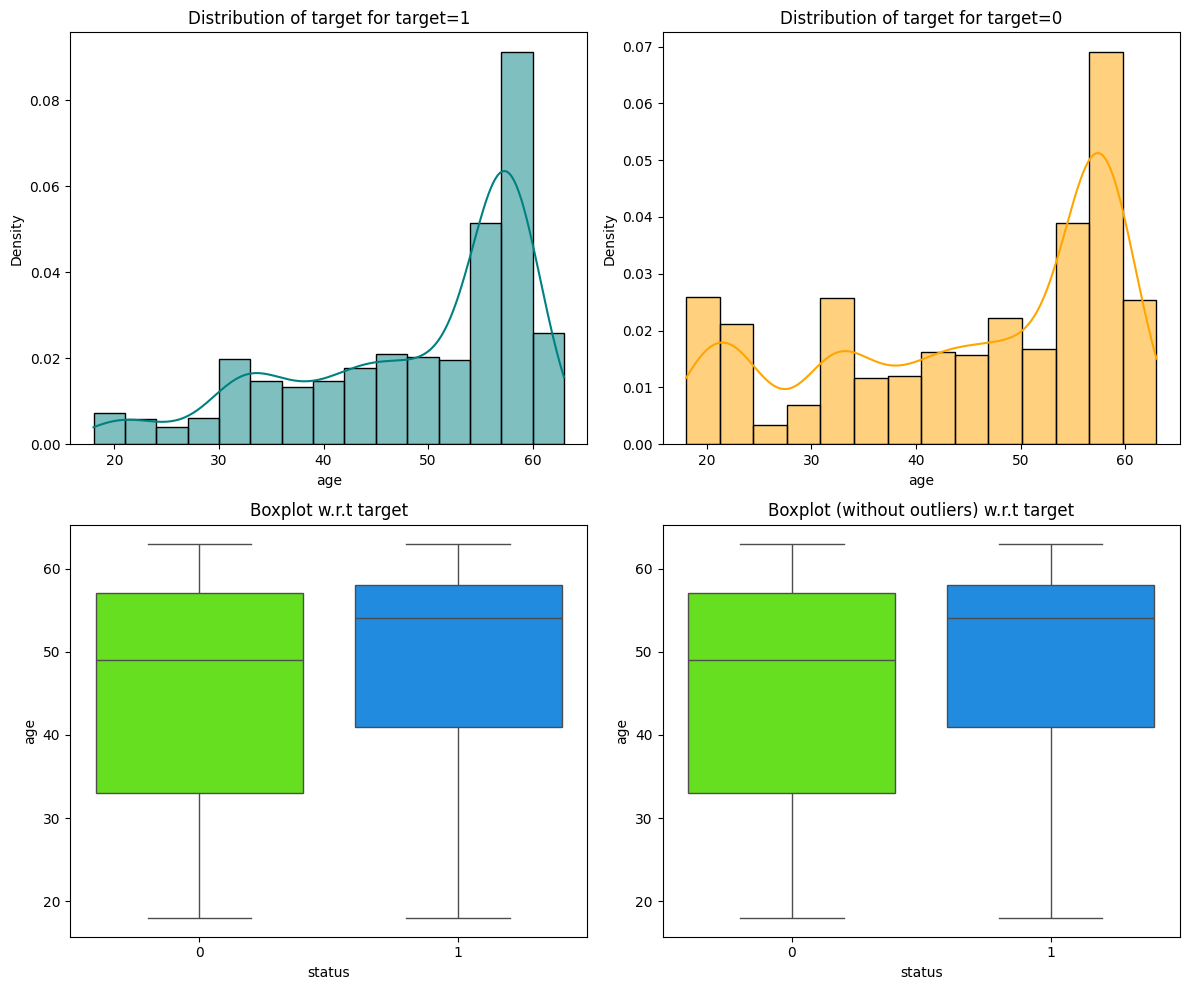

In [ ]:
distribution_plot_wrt_target(df, "age", "status")

Observations: Age does not appear to have a great impact on status.

#### Current Occupation vs. Status

status                 0     1   All
current_occupation                  
All                 3235  1377  4612
Professional        1687   929  2616
Unemployed          1058   383  1441
Student              490    65   555
------------------------------------------------------------------------------------------------------------------------


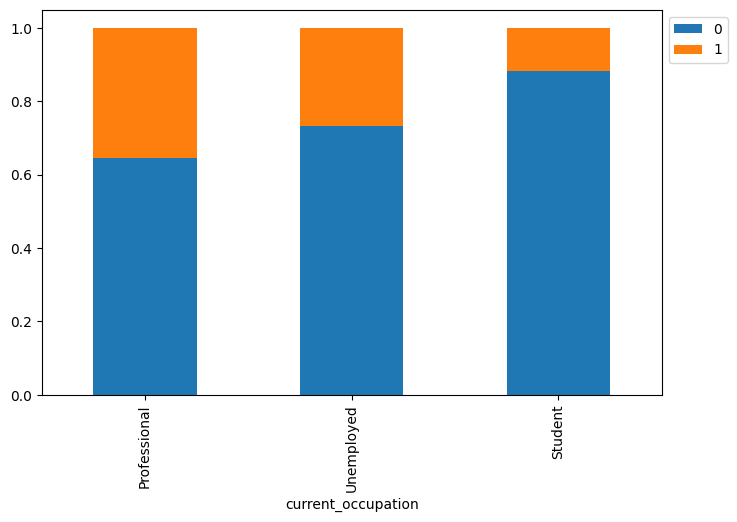

In [ ]:
stacked_barplot(df, "current_occupation", "status")

Observations: Status conversion was more common among leads with professional occupations. This is followed by the unemployed and student occupations.

#### First Interaction vs. Status

status                0     1   All
first_interaction                  
All                3235  1377  4612
Website            1383  1159  2542
Mobile App         1852   218  2070
------------------------------------------------------------------------------------------------------------------------


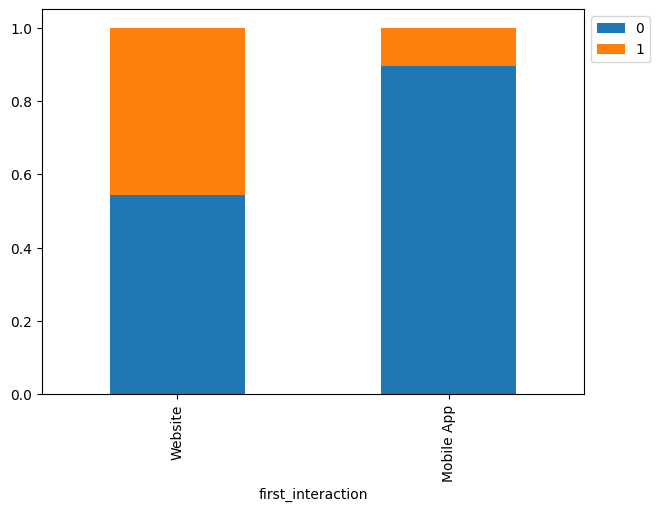

In [ ]:
stacked_barplot(df, "first_interaction", "status")

Observations: Less than half of leads that first interacted with the website converted to a paid customer. This is significantly greater than the leads that interacted with the mobile app and converted to paid customers.

#### Profile Completed vs. Status

status                0     1   All
profile_completed                  
All                3235  1377  4612
High               1318   946  2264
Medium             1818   423  2241
Low                  99     8   107
------------------------------------------------------------------------------------------------------------------------


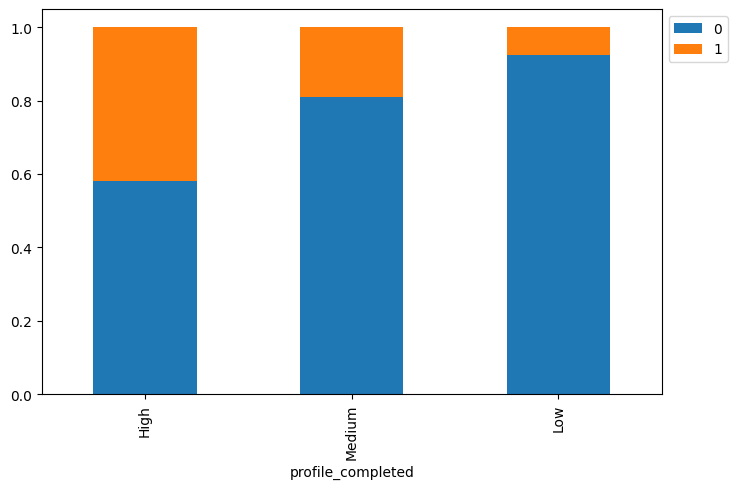

In [ ]:
stacked_barplot(df, "profile_completed", "status")

Observations: Leads that complete greater percentages of their profiles tend to convert to paid customers more. Therefore, knowing more details about a lead can increase the chances of conversion.

#### Website Visits vs. Status

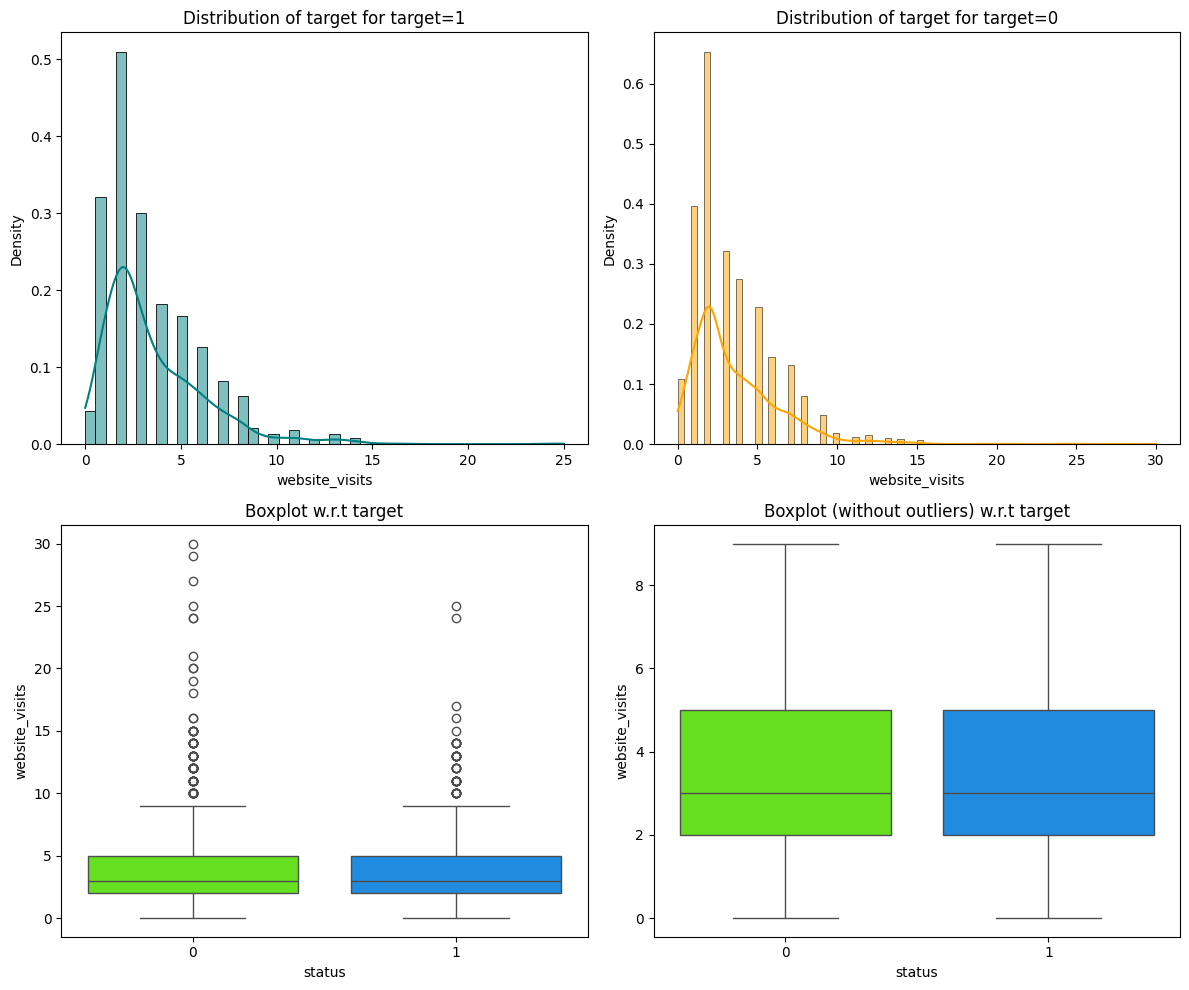

In [ ]:
distribution_plot_wrt_target(df, "website_visits", "status")

Observations: The number of website visits are not a strong indicator of status.

#### Time Spent On Website vs. Status

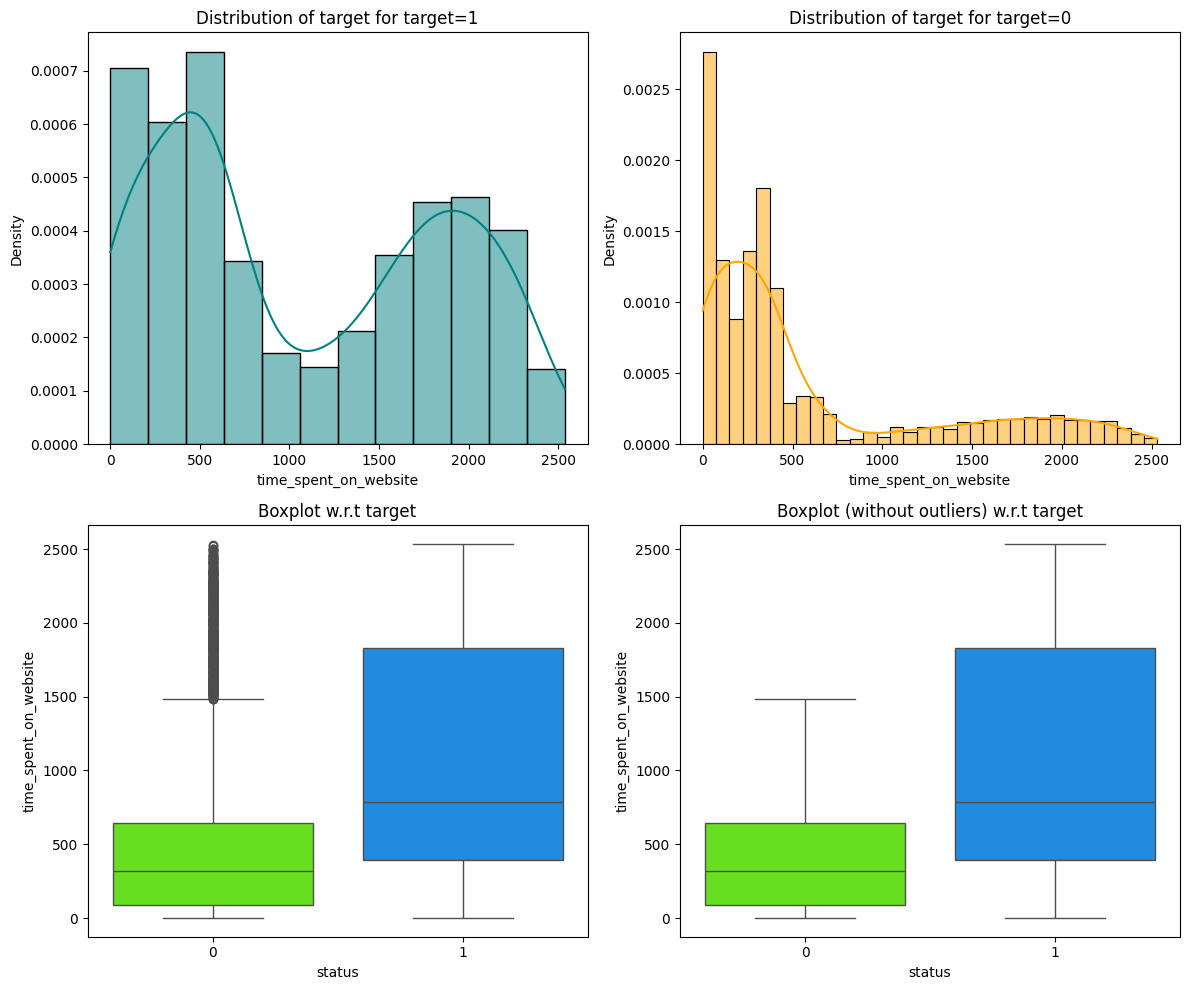

In [ ]:
distribution_plot_wrt_target(df, "time_spent_on_website", "status")

Observations: Leads that become paid customers tend to spend more time browsing the website.

#### Page Views Per Visit vs. Status

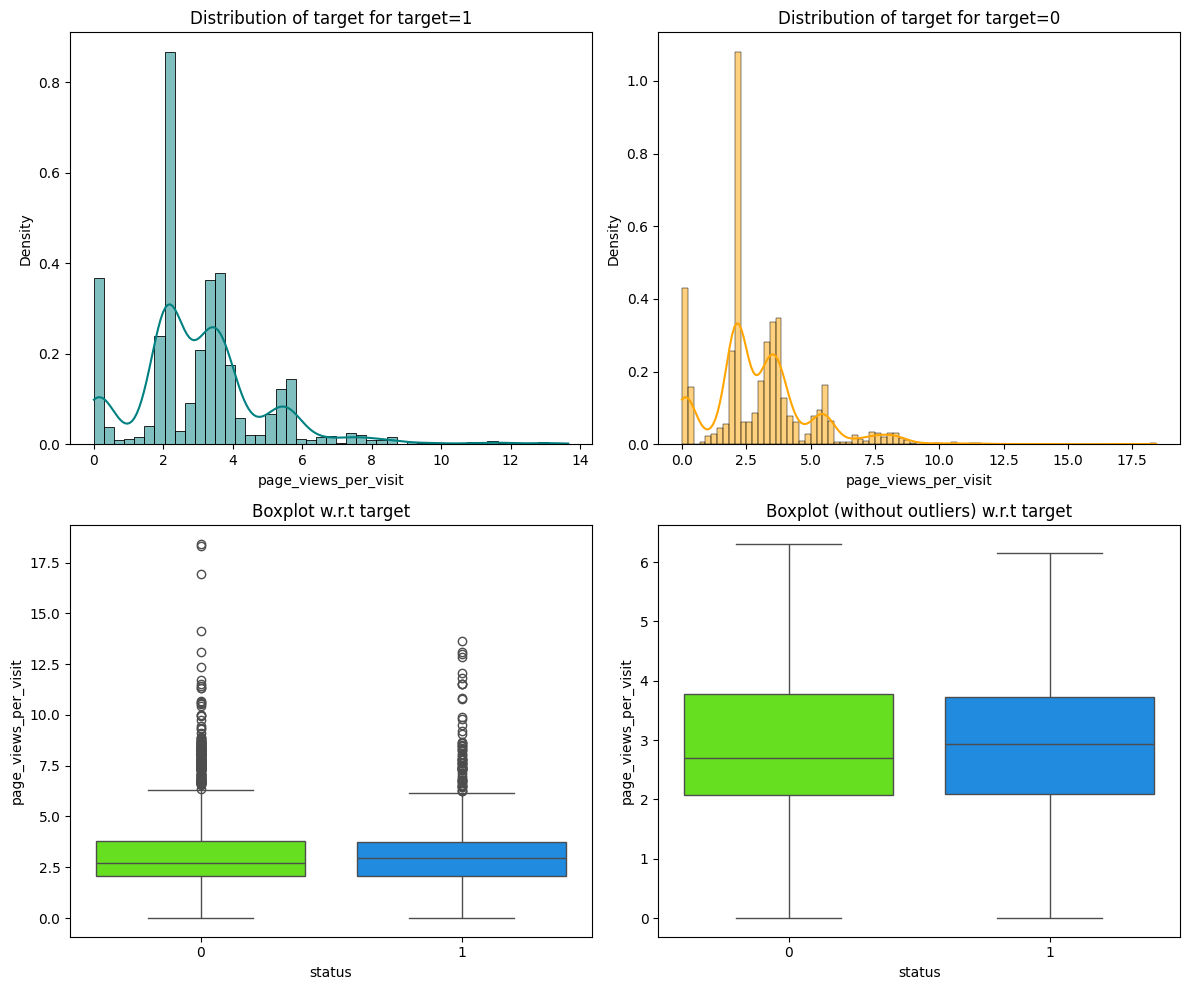

In [ ]:
distribution_plot_wrt_target(df, "page_views_per_visit", "status")

Observations: Page views per visit do not appear to have a significant relationship with status.

#### Last Activity vs. Status

status               0     1   All
last_activity                     
All               3235  1377  4612
Email Activity    1587   691  2278
Website Activity   677   423  1100
Phone Activity     971   263  1234
------------------------------------------------------------------------------------------------------------------------


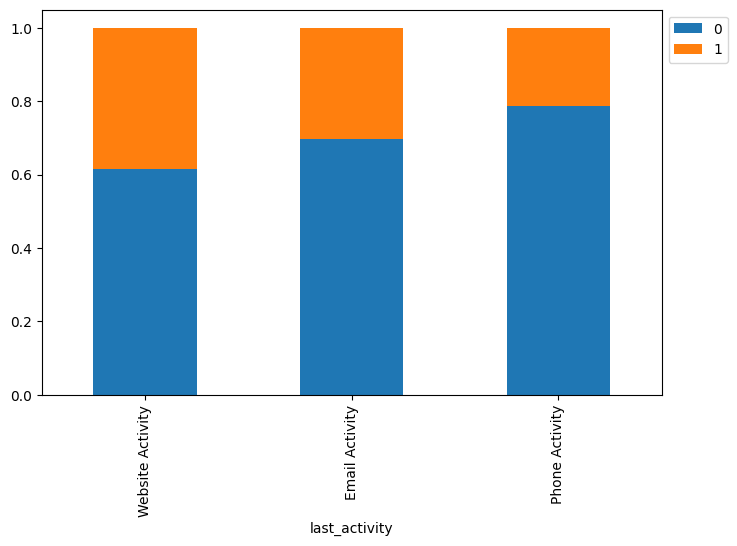

In [ ]:
stacked_barplot(df, "last_activity", "status")

Observations: Leads that last interacted via website appear to become customers more often than those with email or phone activity.

#### Print Media Type 1 (Newspaper) vs. Status

status                0     1   All
print_media_type1                  
All                3235  1377  4612
No                 2897  1218  4115
Yes                 338   159   497
------------------------------------------------------------------------------------------------------------------------


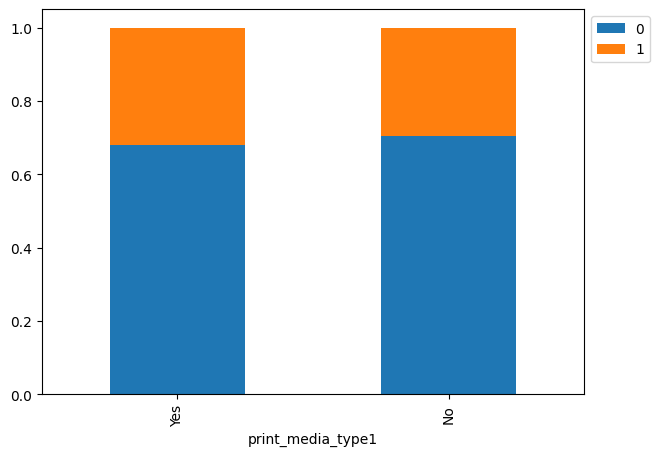

In [ ]:
stacked_barplot(df, "print_media_type1", "status")

Observations: Seeing the ad via newspaper does not seem to have a great effect on status.

####Print Media Type 2 (Magazine) vs. Status

status                0     1   All
print_media_type2                  
All                3235  1377  4612
No                 3077  1302  4379
Yes                 158    75   233
------------------------------------------------------------------------------------------------------------------------


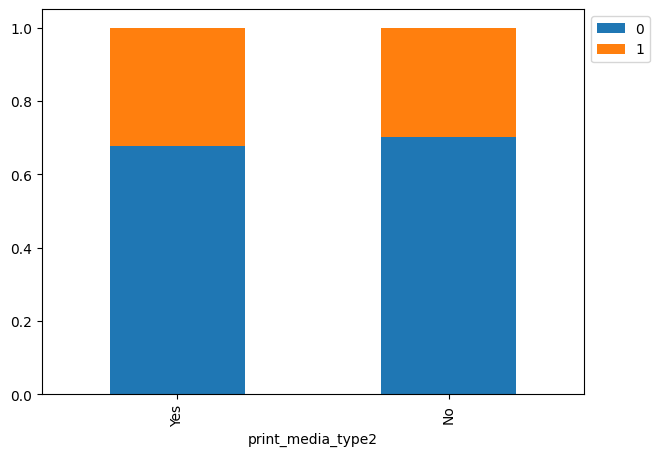

In [ ]:
stacked_barplot(df, "print_media_type2", "status")

Observations: Seeing the ad via magazine does not seem to impact status either.

#### Digital Media vs. Status

status            0     1   All
digital_media                  
All            3235  1377  4612
No             2876  1209  4085
Yes             359   168   527
------------------------------------------------------------------------------------------------------------------------


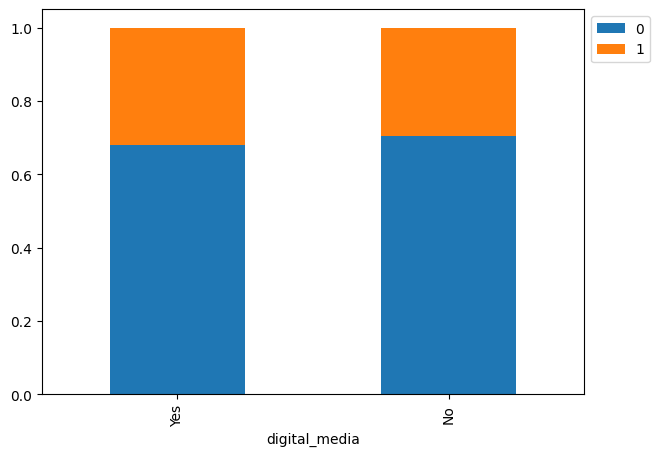

In [ ]:
stacked_barplot(df, "digital_media", "status")

Observations: Seeing the ad on digital media does not seem to affect status.

#### Educational Channels vs. Status

status                   0     1   All
educational_channels                  
All                   3235  1377  4612
No                    2727  1180  3907
Yes                    508   197   705
------------------------------------------------------------------------------------------------------------------------


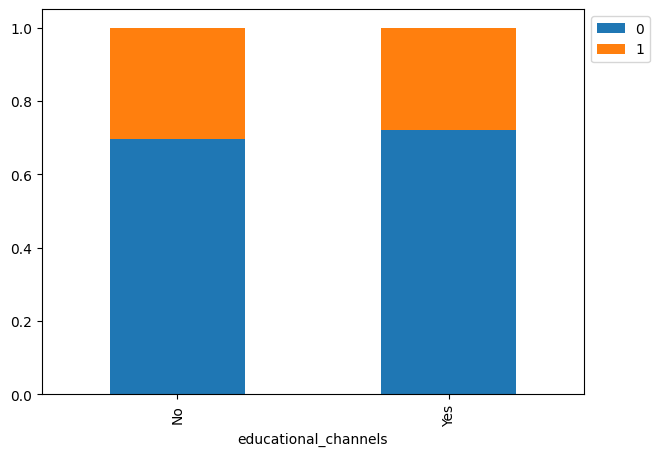

In [ ]:
stacked_barplot(df, "educational_channels", "status")

Observations: Hearing about ExtraaLearn via educational channels does not appear to have a significant effect on status.

####Referral vs. Status

status       0     1   All
referral                  
All       3235  1377  4612
No        3205  1314  4519
Yes         30    63    93
------------------------------------------------------------------------------------------------------------------------


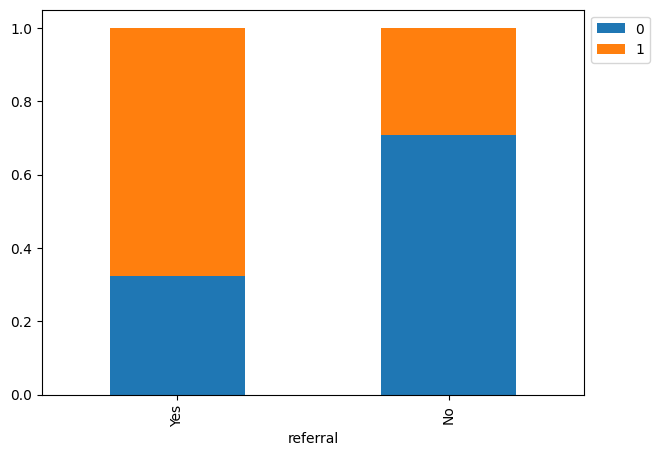

In [ ]:
stacked_barplot(df, "referral", "status")

Observations: Hearing about ExtraaLearn via reference does appear to have an effect on status. Out of all the channels, reference has the highest status conversion rates (~65%).

## Data Preprocessing

- Missing value treatment (if needed)
- Feature engineering (if needed)
- Outlier detection and treatment (if needed)
- Preparing data for modeling
- Any other preprocessing steps (if needed)

### Outlier Check

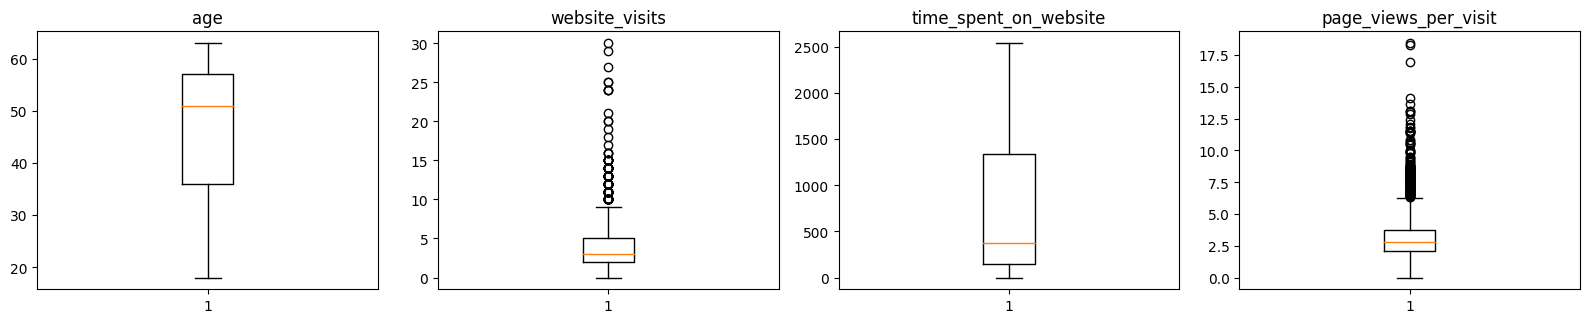

In [ ]:
# outlier detection using boxplot
numeric_columns = data.select_dtypes(include=np.number).columns.tolist()
numeric_columns.remove("status")

plt.figure(figsize=(16, 12))

for i, variable in enumerate(numeric_columns):
    plt.subplot(4, 4, i + 1)
    plt.boxplot(data[variable], whis=1.5)
    plt.tight_layout()
    plt.title(variable)

plt.show()

Observations: Website_visits and page_views_per_visit contain outliers. However, they will not be treated because they are proper values.

### Custom Functions

In [ ]:
# computes different metrics to check classification model performance
def model_performance_classification_statsmodels(
    model, predictors, target, threshold=0.5
):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    threshold: threshold for classifying the observation as class 1
    """

    # checking which probabilities are greater than threshold
    pred_temp = model.predict(predictors) > threshold
    # rounding off the above values to get classes
    pred = np.round(pred_temp)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [ ]:
# plots classification model confusion matrix


def confusion_matrix_statsmodels(model, predictors, target, threshold=0.5):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    threshold: threshold for classifying the observation as class 1
    """
    y_pred = model.predict(predictors) > threshold
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

Note: Will prioritize recall score to minimize false negatives that lead to lost customers.

## EDA

- It is a good idea to explore the data once again after manipulating it.

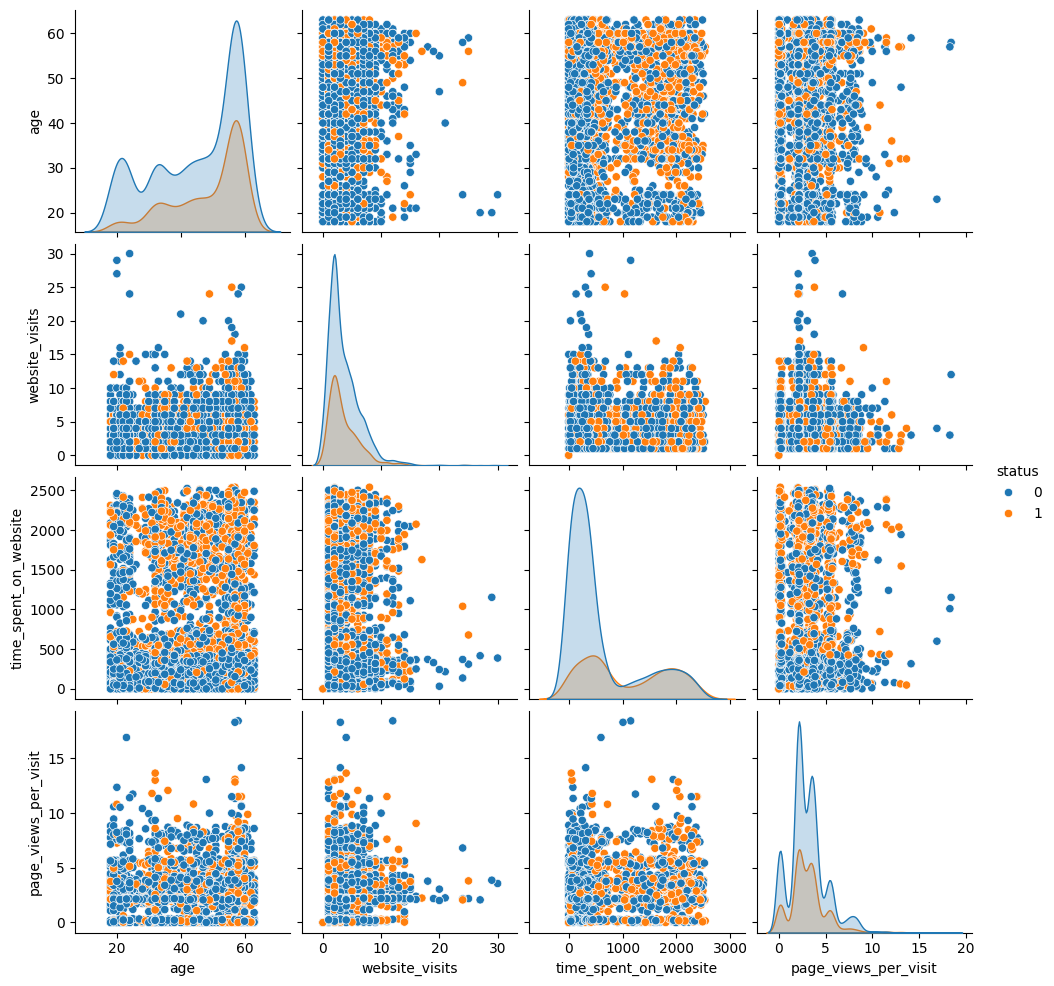

In [ ]:
sns.pairplot(df, hue="status", diag_kind="kde")

## Building a Logistic Regression Model

In [ ]:
X = df.drop("status", axis=1)
y = df["status"]

X = sm.add_constant(X)
X = pd.get_dummies(X, drop_first=True)

# splits data into test and train sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1
)
X_train, X_test = X_train.astype(float), X_test.astype(float)

In [ ]:
print("Shape of training set:", X_train.shape)
print("Shape of test set:", X_test.shape)

Shape of training set: (3228, 17)
Shape of test set: (1384, 17)


In [ ]:
# fits logistic regression model
logit = sm.Logit(y_train, X_train)
lg = logit.fit(disp=False)
print(lg.summary())

                           Logit Regression Results                           
Dep. Variable:                 status   No. Observations:                 3228
Model:                          Logit   Df Residuals:                     3211
Method:                           MLE   Df Model:                           16
Date:                Mon, 19 May 2025   Pseudo R-squ.:                  0.3589
Time:                        05:45:51   Log-Likelihood:                -1256.8
converged:                       True   LL-Null:                       -1960.4
Covariance Type:            nonrobust   LLR p-value:                4.576e-290
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const                             -2.3415      0.309     -7.580      0.000      -2.947      -1.736
age                               -0.0023      0.005     -0.443      0.

In [ ]:
print("Training Performance:")
model_performance_classification_statsmodels(lg, X_train, y_train)

Training Performance:


,Accuracy,Recall,Precision,F1
0,0.82776,0.66178,0.73064,0.69451


### Checking Multicollinearity

- In order to make statistical inferences from a logistic regression model, it is important to ensure that there is no multicollinearity present in the data.

In [ ]:
# checks VIF for each variable
def checking_vif(predictors):
  vif = pd.DataFrame()
  vif["Features"] = predictors.columns
  vif["VIF"] = [
      variance_inflation_factor(predictors.values, i)
      for i in range(predictors.shape[1])
  ]
  return(vif)

In [ ]:
checking_vif(X_train)

,Features,VIF
0,const,38.00376
1,age,1.97547
2,website_visits,1.01606
3,time_spent_on_website,1.02318
4,page_views_per_visit,1.01711
5,current_occupation_Student,2.02624
6,current_occupation_Unemployed,1.07083
7,first_interaction_Website,1.00842
8,profile_completed_Low,1.03701
9,profile_completed_Medium,1.02992


Observations: None of the variables exhibit moderate or high multicollinearity.

### Dropping High P-Value Variables

In [ ]:
cols = X_train.columns.tolist()
max_p_value = 1

while len(cols) > 0:
    X_train_aux = X_train[cols]

    # fits model
    lr_model = sm.Logit(y_train, X_train_aux).fit(disp=False)
    p_values = lr_model.pvalues
    max_p_value = max(p_values)
    remove_variable = p_values.idxmax()

    # removes columns with p_values greater than 0.05
    if max_p_value > 0.05:
        cols.remove(remove_variable)
    else:
        break

# prints remaining columns
selected_columns = cols
print(selected_columns)

['const', 'time_spent_on_website', 'current_occupation_Student', 'current_occupation_Unemployed', 'first_interaction_Website', 'profile_completed_Low', 'profile_completed_Medium', 'last_activity_Phone Activity', 'last_activity_Website Activity', 'print_media_type2_Yes', 'referral_Yes']


In [ ]:
X_train1 = X_train[selected_columns]
X_test1 = X_test[selected_columns]

logit1 = sm.Logit(y_train, X_train1)
lg1 = logit1.fit(disp=False)
print(lg1.summary())

                           Logit Regression Results                           
Dep. Variable:                 status   No. Observations:                 3228
Model:                          Logit   Df Residuals:                     3217
Method:                           MLE   Df Model:                           10
Date:                Mon, 19 May 2025   Pseudo R-squ.:                  0.3576
Time:                        05:45:52   Log-Likelihood:                -1259.3
converged:                       True   LL-Null:                       -1960.4
Covariance Type:            nonrobust   LLR p-value:                3.443e-295
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const                             -2.4977      0.141    -17.732      0.000      -2.774      -2.222
time_spent_on_website              0.0012   7.06e-05     17.546      0.

Observations:

*   Increases in time_spent_on_website, first_interaction_Website, last_activity_Website Activity, print_media_type2_Yes, and referral_Yes will increase the chances of leads converting to paid customers (direct relationships).
*    On the other hand, increases in current_occupation_Student, current_occupation_Unemployed, profile_completed_Low, profile_completed_Medium, and last_activity_Phone Activity will decrease the chances of leads converting to paid customers (inverse relationships).



In [ ]:
print("Training Performance:")
model_performance_classification_statsmodels(lg1, X_train1, y_train)

Training Performance:


,Accuracy,Recall,Precision,F1
0,0.82714,0.65969,0.73001,0.69307


Observations: The data only has variables with p-values less than 0.05. The training performance is generally the same, but recall decreased very slightly.

### Converting Coefficients to Odds

In [ ]:
odds = np.exp(lg1.params)
perc_odds_change = (np.exp(lg1.params) - 1) * 100
odds_df = pd.DataFrame({"Odds": odds, "% Odd Change": perc_odds_change}, index=X_train1.columns).T
odds_df

,const,time_spent_on_website,current_occupation_Student,current_occupation_Unemployed,first_interaction_Website,profile_completed_Low,profile_completed_Medium,last_activity_Phone Activity,last_activity_Website Activity,print_media_type2_Yes,referral_Yes
Odds,0.08227,1.00124,0.11744,0.55554,15.14700,0.08428,0.17184,0.49833,1.58873,1.58662,4.95606
% Odd Change,-91.77267,0.12387,-88.25648,-44.44627,1414.70043,-91.57176,-82.81597,-50.16732,58.87331,58.66203,395.60635


Observations:


*   time_spent_on_website: A 1 unit change in time spent on website will increase the odds of a status conversion by 0.12%.
*   current_occupation_Student: Student leads are 88.26% less likely to convert to paid customers.
* current_occupation_Unemployed: Unemployed leads are 44.45% less likely to convert to paid customers.
* first_interaction_Website: Leads that first interact with the website are 1414.7% more likely to convert to paid customers.
* profile_completed_Low: Leads that complete a low percent of their profile are 91.57% less likely to become paid customers.
* profile_completed_Medium: Leads that complete a moderate percent of their profile are 82.82% less likely to become paid customers.
* last_activity_Phone Activity: Leads that last interacted via phone have 50.17% lower odds of becoming paid customers.
* last_activity_Website Activity: Leads that last interacted via website have 58.87% greater odds of becoming paid customers.
* print_media_type2_Yes: Leads that saw the ad via newspaper have 58.66% greater odds of becoming paid customers.
* referral_Yes: Leads that were referred have 395.61% greater odds of becoming paid customers.



## Model Performance Evaluation

#### Checking Model Performance on Training Set

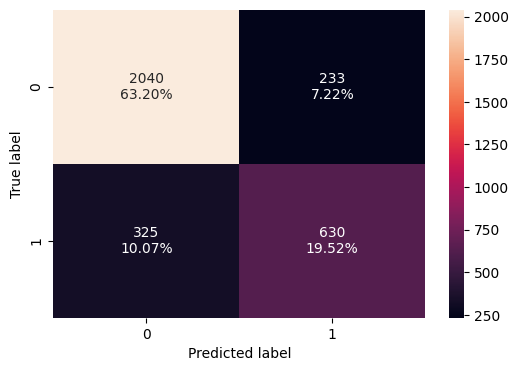

In [ ]:
confusion_matrix_statsmodels(lg1, X_train1, y_train)

In [ ]:
print("Training Performance:")
log_reg_model_train_performance = model_performance_classification_statsmodels(lg1, X_train1, y_train)
log_reg_model_train_performance

Training Performance:


,Accuracy,Recall,Precision,F1
0,0.82714,0.65969,0.73001,0.69307


#### Checking Model Performance on Test Set

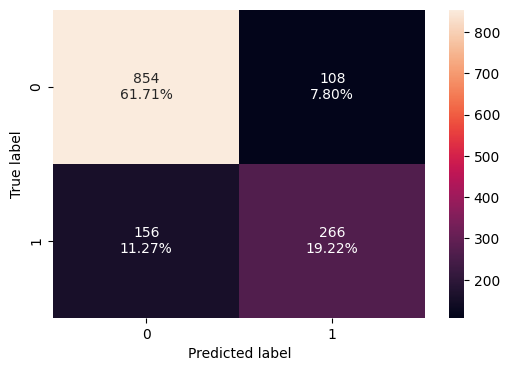

In [ ]:
confusion_matrix_statsmodels(lg1, X_test1, y_test)

In [ ]:
print("Test Performance:")
log_reg_model_test_performance = model_performance_classification_statsmodels(lg1, X_test1, y_test)
log_reg_model_test_performance

Test Performance:


,Accuracy,Recall,Precision,F1
0,0.80925,0.63033,0.71123,0.66834


### ROC-AUC

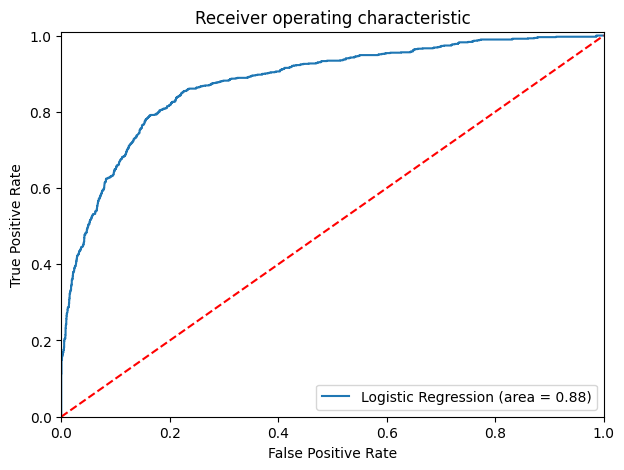

In [ ]:
logit_roc_auc_train = roc_auc_score(y_train, lg1.predict(X_train1))
fpr, tpr, thresholds = roc_curve(y_train, lg1.predict(X_train1))
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label="Logistic Regression (area = %0.2f)" % logit_roc_auc_train)
plt.plot([0, 1], [0, 1], "r--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.01])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver operating characteristic")
plt.legend(loc="lower right")
plt.show()

#### Checking Model Performance on Training Set

0.26219074882782695


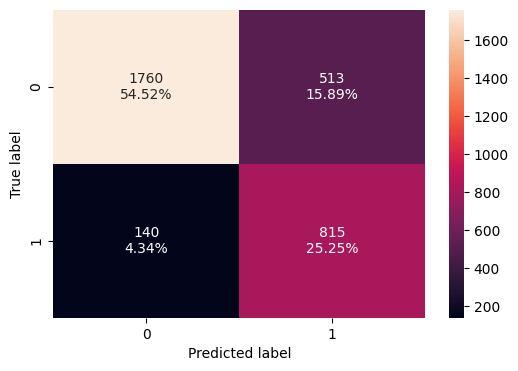

In [ ]:
fpr, tpr, thresholds = roc_curve(y_train, lg1.predict(X_train1))

optimal_idx = np.argmax(tpr - fpr)
optimal_threshold_auc_roc = thresholds[optimal_idx]
print(optimal_threshold_auc_roc)

confusion_matrix_statsmodels(lg1, X_train1, y_train, optimal_threshold_auc_roc)

In [ ]:
log_reg_model_train_perf_threshold_auc_roc = model_performance_classification_statsmodels(
    lg1, X_train1, y_train, threshold=optimal_threshold_auc_roc
)
print("Training performance:")
log_reg_model_train_perf_threshold_auc_roc

Training performance:


,Accuracy,Recall,Precision,F1
0,0.79771,0.85340,0.61370,0.71397


Observations: Recall has improved dramatically on the training set.

#### Checking Model Performance on Test Set

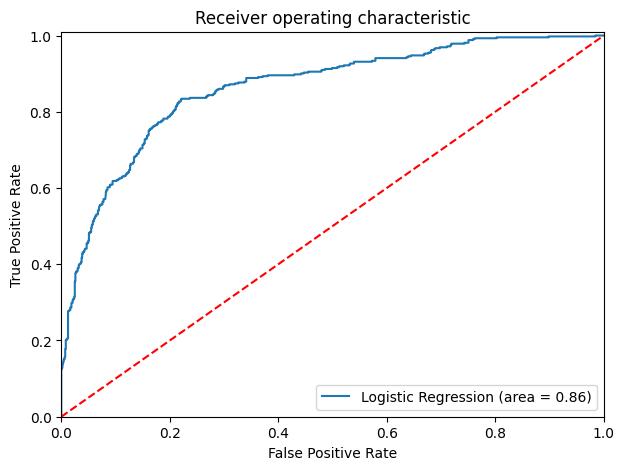

In [ ]:
logit_roc_auc_test = roc_auc_score(y_test, lg1.predict(X_test1))
fpr, tpr, thresholds = roc_curve(y_test, lg1.predict(X_test1))
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label="Logistic Regression (area = %0.2f)" % logit_roc_auc_test)
plt.plot([0, 1], [0, 1], "r--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.01])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver operating characteristic")
plt.legend(loc="lower right")
plt.show()

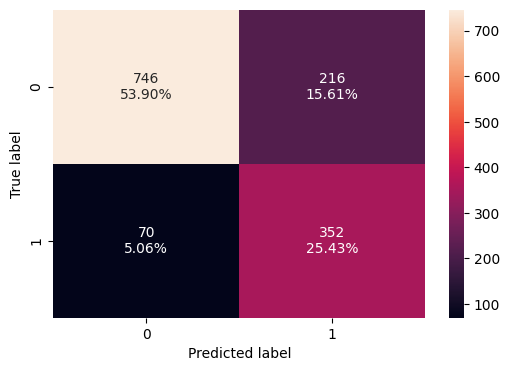

In [ ]:
confusion_matrix_statsmodels(lg1, X_test1, y_test, threshold=optimal_threshold_auc_roc)

In [ ]:
log_reg_model_test_perf_threshold_auc_roc = model_performance_classification_statsmodels(
    lg1, X_test1, y_test, threshold=optimal_threshold_auc_roc
)
print("Test performance:")
log_reg_model_test_perf_threshold_auc_roc

Test performance:


,Accuracy,Recall,Precision,F1
0,0.79335,0.83412,0.61972,0.71111


Observations: The difference between training and test set performance is low.

### Precision-Recall Curve

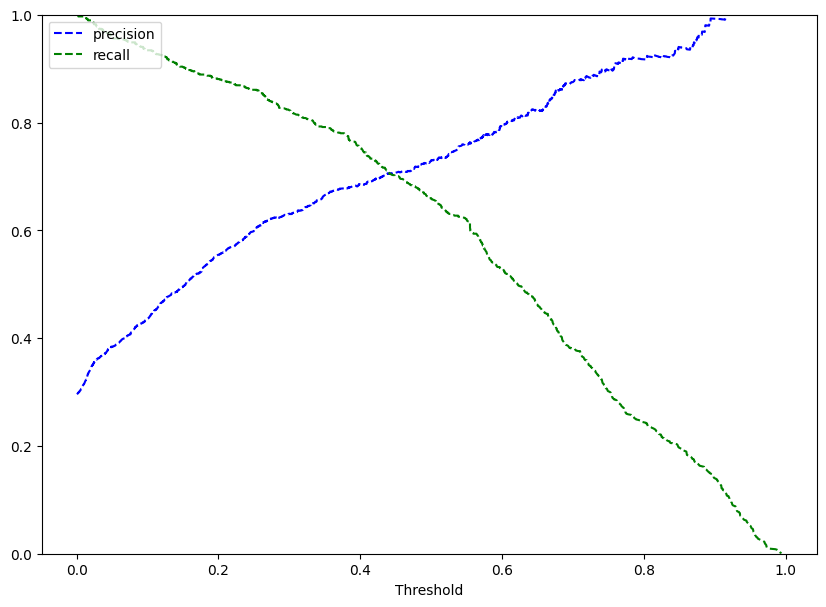

In [ ]:
y_scores = lg1.predict(X_train1)
prec, rec, tre = precision_recall_curve(y_train, y_scores,)


def plot_prec_recall_vs_tresh(precisions, recalls, thresholds):
    plt.plot(thresholds, precisions[:-1], "b--", label="precision")
    plt.plot(thresholds, recalls[:-1], "g--", label="recall")
    plt.xlabel("Threshold")
    plt.legend(loc="upper left")
    plt.ylim([0, 1])


plt.figure(figsize=(10, 7))
plot_prec_recall_vs_tresh(prec, rec, tre)
plt.show()

In [ ]:
optimal_threshold_curve = 0.42

Observations: 0.42 is a balanced threshold between precision and recall.

#### Checking Model Performance on Training Set

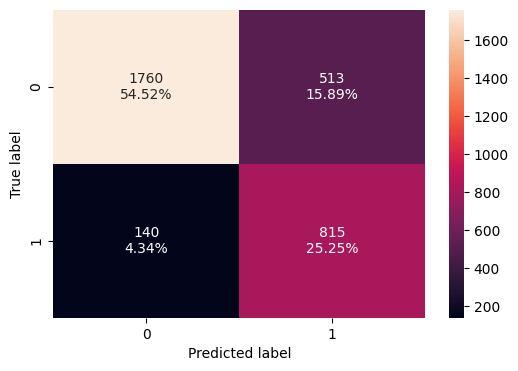

In [ ]:
confusion_matrix_statsmodels(lg1, X_train1, y_train, threshold=optimal_threshold_auc_roc)

In [ ]:
log_reg_model_train_perf_threshold_pr = model_performance_classification_statsmodels(
    lg1, X_train1, y_train, threshold=optimal_threshold_curve
)
print("Training Performance:")
log_reg_model_train_perf_threshold_pr

Training Performance:


,Accuracy,Recall,Precision,F1
0,0.82466,0.72984,0.69353,0.71122


#### Checking Model Performance on Test Set

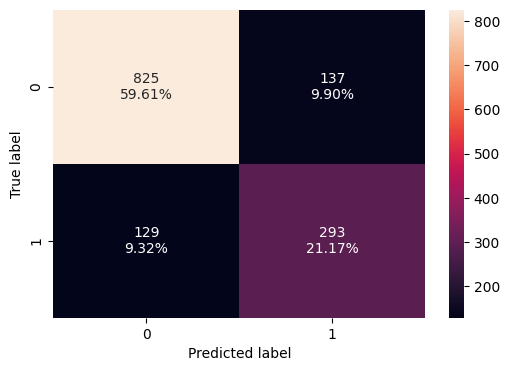

In [ ]:
confusion_matrix_statsmodels(lg1, X_test1, y_test, threshold=optimal_threshold_curve)

In [ ]:
log_reg_model_test_perf_threshold_pr = model_performance_classification_statsmodels(
    lg1, X_test1, y_test, threshold=optimal_threshold_curve
)
print("Test Performance:")
log_reg_model_test_perf_threshold_pr

Test Performance:


,Accuracy,Recall,Precision,F1
0,0.80780,0.69431,0.68140,0.68779


Observations: Recall is slightly lower for the test set.

## Final Model Summary

In [ ]:
# training performances
models_train_performance = pd.concat(
    [
        log_reg_model_train_performance.T,
        log_reg_model_train_perf_threshold_auc_roc.T,
        log_reg_model_train_perf_threshold_pr.T,
    ]
    , axis=1
)
models_train_performance.columns = [
    "Logistic Regression", "Logistic Regression (AUC-ROC)", "Logistic Regression (PR)"
    ]
print("Training Performance Comparison:")
models_train_performance

Training Performance Comparison:


,Logistic Regression,Logistic Regression (AUC-ROC),Logistic Regression (PR)
Accuracy,0.82714,0.79771,0.82466
Recall,0.65969,0.85340,0.72984
Precision,0.73001,0.61370,0.69353
F1,0.69307,0.71397,0.71122


In [ ]:
# test performances
models_test_performance = pd.concat(
    [
        log_reg_model_test_performance.T,
        log_reg_model_test_perf_threshold_auc_roc.T,
        log_reg_model_test_perf_threshold_pr.T,
    ]
    , axis=1
)
models_test_performance.columns = [
    "Logistic Regression", "Logistic Regression (AUC-ROC)", "Logistic Regression (PR)"
    ]
print("Test Performance Comparison:")
models_test_performance

Test Performance Comparison:


,Logistic Regression,Logistic Regression (AUC-ROC),Logistic Regression (PR)
Accuracy,0.80925,0.79335,0.80780
Recall,0.63033,0.83412,0.69431
Precision,0.71123,0.61972,0.68140
F1,0.66834,0.71111,0.68779


Observations: The logistic regression model that uses the AUC-ROC threshold has the best recall metric and is better at reducing false negatives.

## Building a Decision Tree Model

In [ ]:
X = df.drop(["status"], axis=1)
y = df["status"]

X = pd.get_dummies(X, drop_first=True)

# Splitting data in train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=1
)

In [ ]:
dt_model = DecisionTreeClassifier(random_state=1)
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=1)

#### Checking Model Performance on Training Set

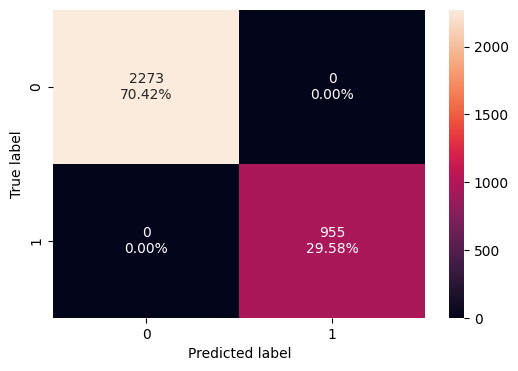

In [ ]:
confusion_matrix_statsmodels(dt_model, X_train, y_train)

In [ ]:
decision_tree_model_train_performance = model_performance_classification_statsmodels(dt_model, X_train, y_train)
decision_tree_model_train_performance

,Accuracy,Recall,Precision,F1
0,1.00000,1.00000,1.00000,1.00000


#### Checking Model Performance on Test Set

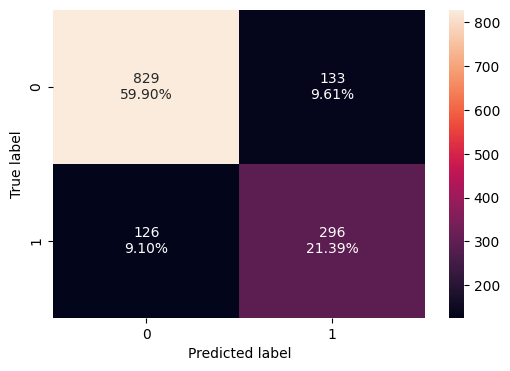

In [ ]:
confusion_matrix_statsmodels(dt_model, X_test, y_test)

In [ ]:
decision_tree_model_test_performance = model_performance_classification_statsmodels(dt_model, X_test, y_test)
decision_tree_model_test_performance

,Accuracy,Recall,Precision,F1
0,0.81286,0.70142,0.68998,0.69565


Observations: The model is overfitting the training data and cannot generalize to the test set.

## Do we need to prune the tree?

Since the model is overfitting the training data, we will have to prune the decision tree.

### Feature Importance

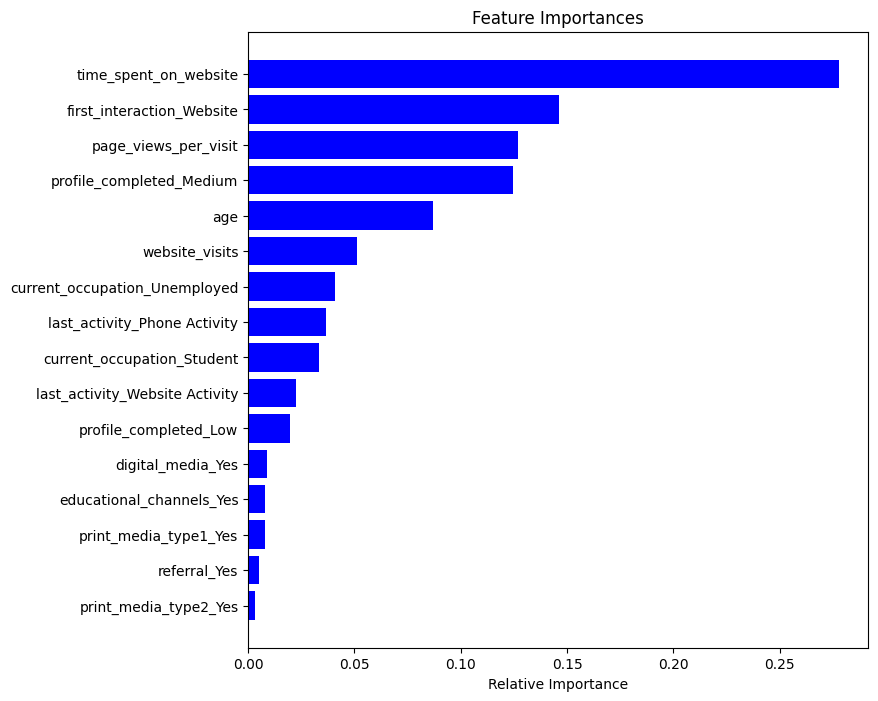

In [ ]:
feature_names = list(X_train.columns)
importances = dt_model.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(8, 8))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="blue", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

Observations: Time spent on website is the most important feature.

### Pruning

In [ ]:
estimator = DecisionTreeClassifier(random_state=1, class_weight={0: 0.3, 1: 0.7})
parameters = {
    "max_depth": np.arange(5, 13, 2),
    "max_leaf_nodes": [10, 20, 40, 50, 75, 100],
    "min_samples_split": [2, 5, 7, 10, 20, 30],
}
acc_scorer = make_scorer(accuracy_score)
grid_obj = GridSearchCV(estimator, parameters, scoring=acc_scorer, cv=5)
grid_obj = grid_obj.fit(X_train, y_train)

estimator = grid_obj.best_estimator_
estimator.fit(X_train, y_train)

DecisionTreeClassifier(class_weight={0: 0.3, 1: 0.7}, max_depth=5,
                       max_leaf_nodes=10, random_state=1)

#### Checking Model Performance on Training Set

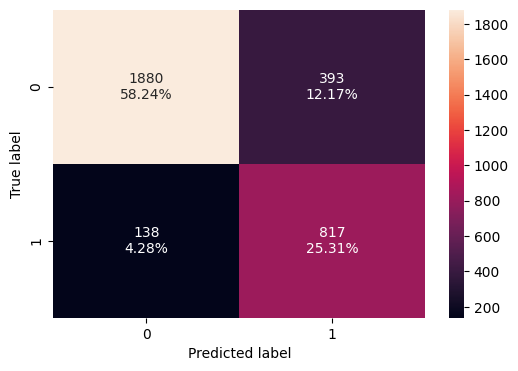

In [ ]:
confusion_matrix_statsmodels(estimator, X_train, y_train)

In [ ]:
decision_tree_train_performance_pruned = model_performance_classification_statsmodels(estimator, X_train, y_train)
decision_tree_train_performance_pruned

,Accuracy,Recall,Precision,F1
0,0.83550,0.85550,0.67521,0.75473


#### Checking Model Performance on Training Set

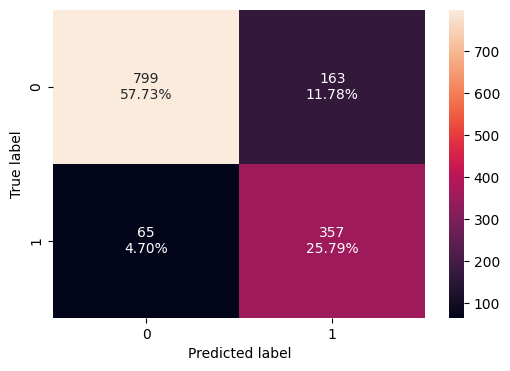

In [ ]:
confusion_matrix_statsmodels(estimator, X_test, y_test)

In [ ]:
decision_tree_test_performance_pruned = model_performance_classification_statsmodels(estimator, X_test, y_test)
decision_tree_test_performance_pruned

,Accuracy,Recall,Precision,F1
0,0.83526,0.84597,0.68654,0.75796


Observations: Overfitting has reduced after pruning.

### Visualizing Decision Tree

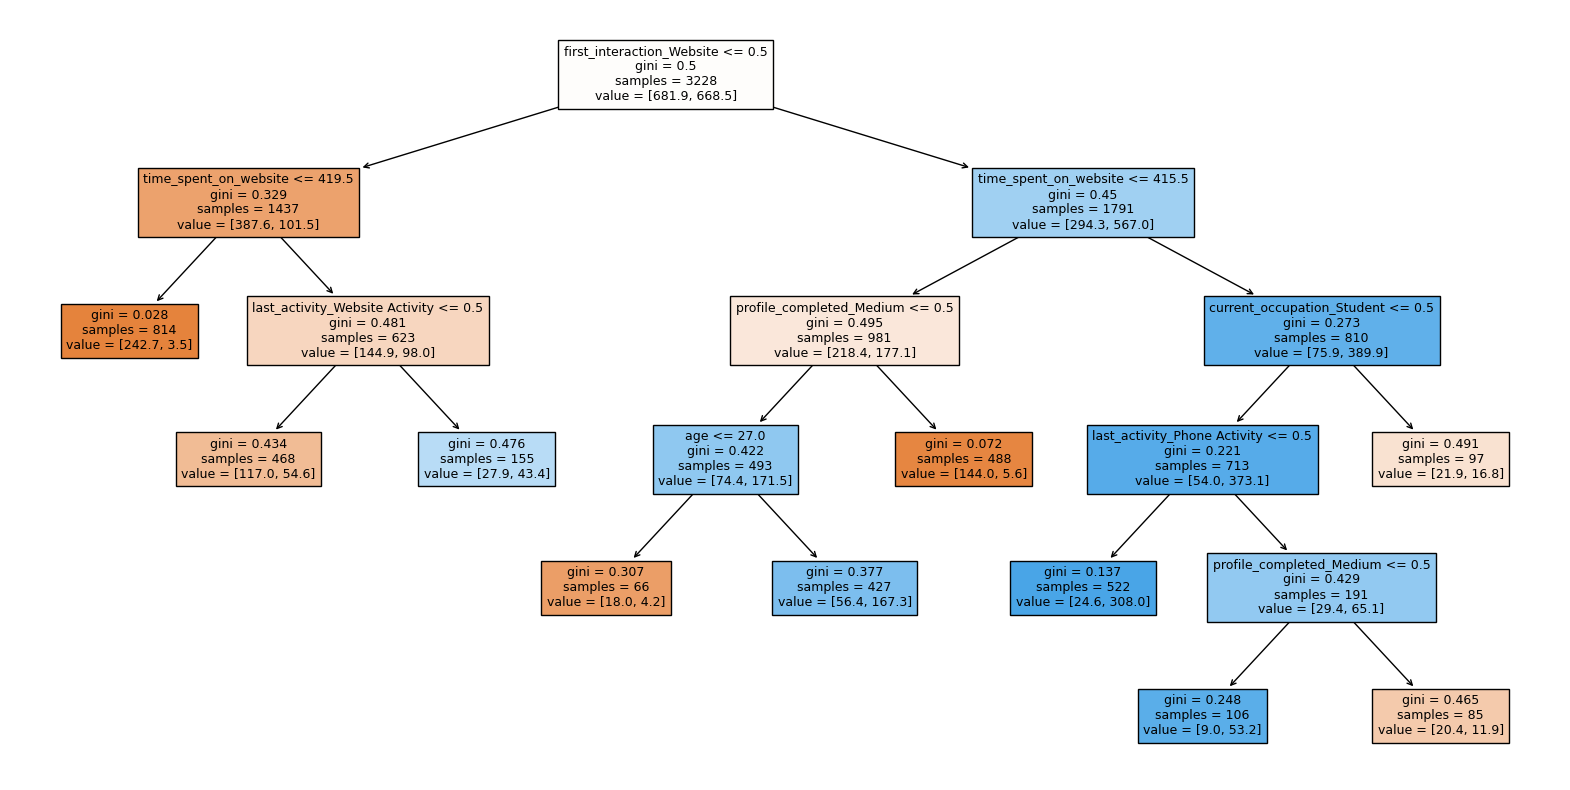

In [ ]:
plt.figure(figsize=(20, 10))
out = tree.plot_tree(
    estimator,
    feature_names=feature_names,
    filled=True,
    fontsize=9,
    node_ids=False,
    class_names=None,
)

for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")
        arrow.set_linewidth(1)
plt.show()

In [ ]:
print(tree.export_text(estimator, feature_names=feature_names, show_weights=True))

|--- first_interaction_Website <= 0.50
|   |--- time_spent_on_website <= 419.50
|   |   |--- weights: [242.70, 3.50] class: 0
|   |--- time_spent_on_website >  419.50
|   |   |--- last_activity_Website Activity <= 0.50
|   |   |   |--- weights: [117.00, 54.60] class: 0
|   |   |--- last_activity_Website Activity >  0.50
|   |   |   |--- weights: [27.90, 43.40] class: 1
|--- first_interaction_Website >  0.50
|   |--- time_spent_on_website <= 415.50
|   |   |--- profile_completed_Medium <= 0.50
|   |   |   |--- age <= 27.00
|   |   |   |   |--- weights: [18.00, 4.20] class: 0
|   |   |   |--- age >  27.00
|   |   |   |   |--- weights: [56.40, 167.30] class: 1
|   |   |--- profile_completed_Medium >  0.50
|   |   |   |--- weights: [144.00, 5.60] class: 0
|   |--- time_spent_on_website >  415.50
|   |   |--- current_occupation_Student <= 0.50
|   |   |   |--- last_activity_Phone Activity <= 0.50
|   |   |   |   |--- weights: [24.60, 308.00] class: 1
|   |   |   |--- last_activity_Phone Act

Observations:

The rules show that first interacting with the website plays an important part in determining if a lead will become a paid customer. Time spent on website is also a strong predictor. The first interaction and last activity channels also affect classification.

**Lead did not first interact with the website:**
* Lead spent less time on the website (<= 419.5):  
  * Lead will almost always not become a paid customer.

* Lead spent more time on the website (> 419.5):
  * If the lead spent more time on the website (>419.5) but their last activity wasn't website-related, they are still less likely to subscribe.
  * On the other hand, if the lead's last activity was website-related, they are more likely to subscribe.

**Lead first interacted with the website:**
* Lead spent less time on the website (<=419.5):
  * If the lead has low-profile completion and is younger than 27, they are less likely to subscribe.
  * If the lead has low-profile completion and is older than 27, they are more likely to subscribe.
  * If the lead has medium-profile completion, they are more likely to subscribe.

* Lead spent more time on the website (> 419.5):
  * If the lead is not a student and did not last interact via the mobile app, they are much more likely to become paid customers.
  * If the lead is a student, they are less likely to subscribe.




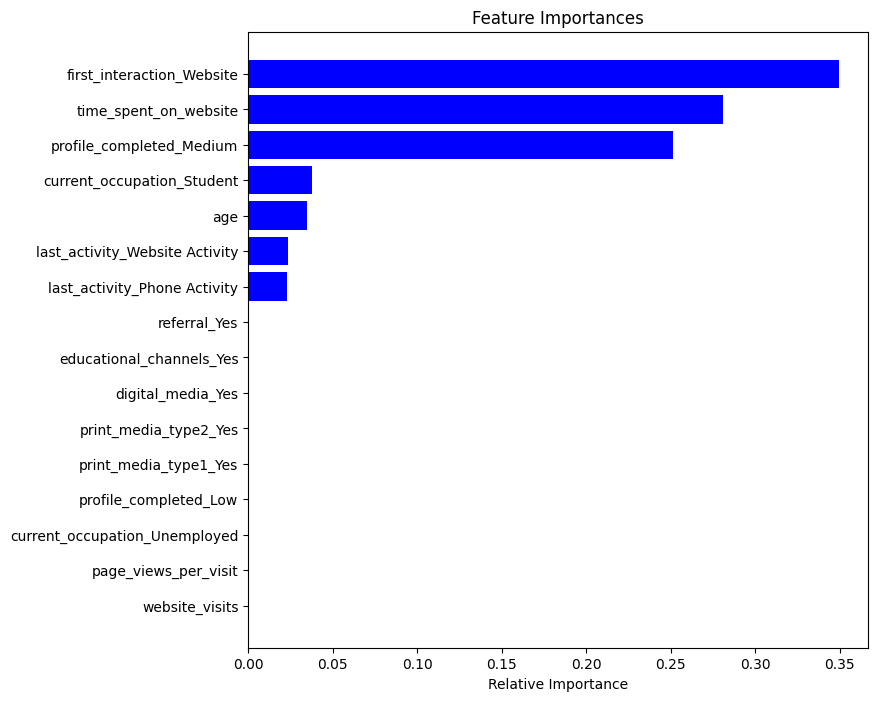

In [ ]:
importances = estimator.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(8, 8))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="blue", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

Observations: After pruning, the most important features are first_interaction_Website, time_spent_on_website, profile_completed_Medium, current_occupation_Student, last_activity_Website Activity, and last_activity_Phone Activity.

### Cost Complexity Pruning

In [ ]:
clf = DecisionTreeClassifier(random_state=1, class_weight="balanced")
path = clf.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = abs(path.ccp_alphas), path.impurities

pd.DataFrame(path)

,ccp_alphas,impurities
0,0.00000,-0.00000
1,0.00000,-0.00000
2,0.00000,-0.00000
3,0.00000,-0.00000
4,0.00000,-0.00000
...,...,...
242,0.00931,0.25997
243,0.01002,0.26999
244,0.02792,0.29790
245,0.05398,0.40586


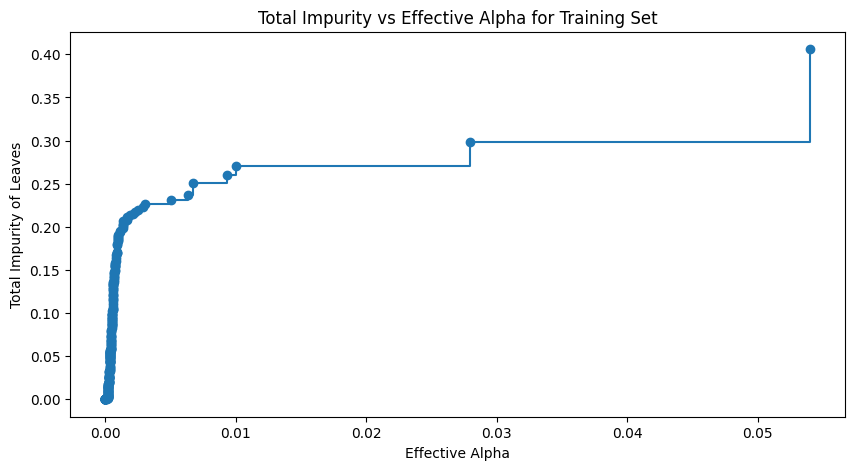

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(ccp_alphas[:-1], impurities[:-1], marker="o", drawstyle="steps-post")
ax.set_xlabel("Effective Alpha")
ax.set_ylabel("Total Impurity of Leaves")
ax.set_title("Total Impurity vs Effective Alpha for Training Set")
plt.show()

In [ ]:
clfs = []
for ccp_alpha in ccp_alphas:
    clf = DecisionTreeClassifier(
        random_state=1, ccp_alpha=ccp_alpha, class_weight="balanced"
    )
    clf.fit(X_train, y_train)
    clfs.append(clf)
print(
    "Number of nodes in the last tree is: {} with ccp_alpha: {}".format(
        clfs[-1].tree_.node_count, ccp_alphas[-1]
    )
)

Number of nodes in the last tree is: 1 with ccp_alpha: 0.0941366086927799


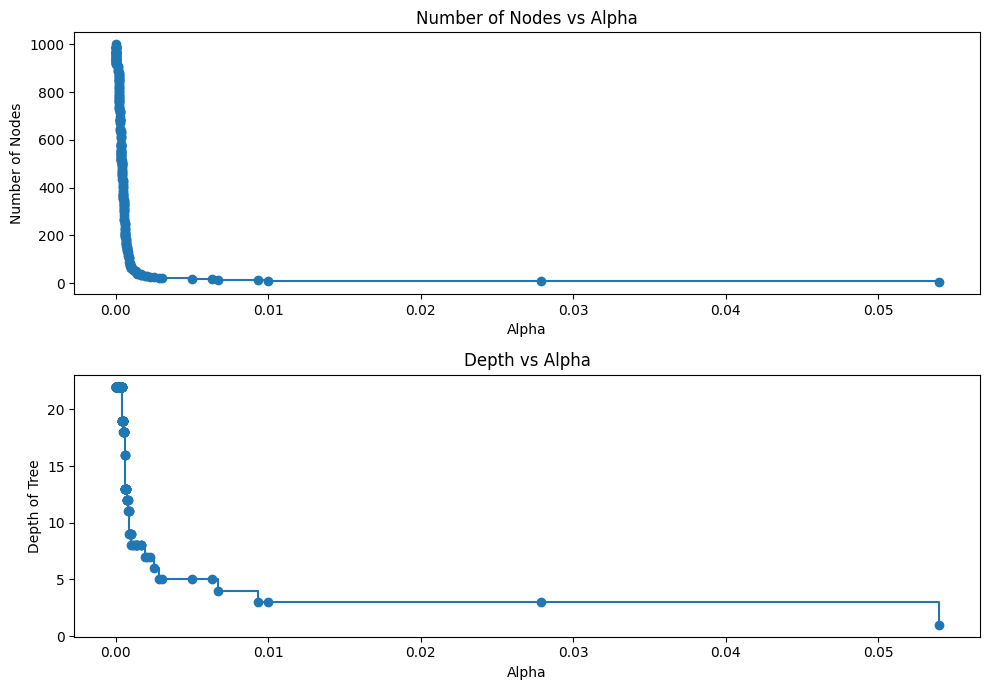

In [ ]:
clfs = clfs[:-1]
ccp_alphas = ccp_alphas[:-1]

node_counts = [clf.tree_.node_count for clf in clfs]
depth = [clf.tree_.max_depth for clf in clfs]
fig, ax = plt.subplots(2, 1, figsize=(10, 7))
ax[0].plot(ccp_alphas, node_counts, marker="o", drawstyle="steps-post")
ax[0].set_xlabel("Alpha")
ax[0].set_ylabel("Number of Nodes")
ax[0].set_title("Number of Nodes vs Alpha")
ax[1].plot(ccp_alphas, depth, marker="o", drawstyle="steps-post")
ax[1].set_xlabel("Alpha")
ax[1].set_ylabel("Depth of Tree")
ax[1].set_title("Depth vs Alpha")
fig.tight_layout()

### Recall Score vs Alpha

In [ ]:
recall_train = []
for clf in clfs:
    pred_train = clf.predict(X_train)
    values_train = recall_score(y_train, pred_train)
    recall_train.append(values_train)

recall_test = []
for clf in clfs:
    pred_test = clf.predict(X_test)
    values_test = recall_score(y_test, pred_test)
    recall_test.append(values_test)

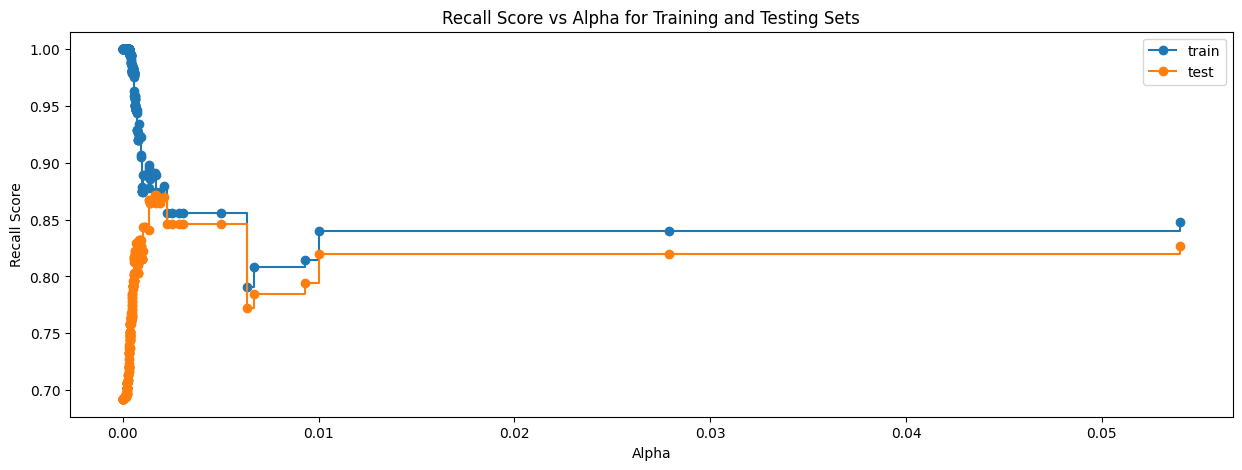

In [ ]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.set_xlabel("Alpha")
ax.set_ylabel("Recall Score")
ax.set_title("Recall Score vs Alpha for Training and Testing Sets")
ax.plot(ccp_alphas, recall_train, marker="o", label="train", drawstyle="steps-post")
ax.plot(ccp_alphas, recall_test, marker="o", label="test", drawstyle="steps-post")
ax.legend()
plt.show()

In [ ]:
index_best_model = np.argmax(recall_test)
best_model = clfs[index_best_model]
print(best_model)

DecisionTreeClassifier(ccp_alpha=0.0016555606975857083, class_weight='balanced',
                       random_state=1)


#### Checking Model Performance on Training Set

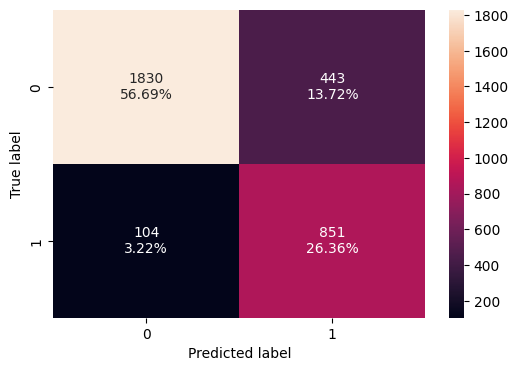

In [ ]:
confusion_matrix_statsmodels(best_model, X_train, y_train)

In [ ]:
decision_tree_post_performance_train = model_performance_classification_statsmodels(best_model, X_train, y_train)
decision_tree_post_performance_train

,Accuracy,Recall,Precision,F1
0,0.83055,0.89110,0.65765,0.75678


#### Checking Model Performance on Test Set

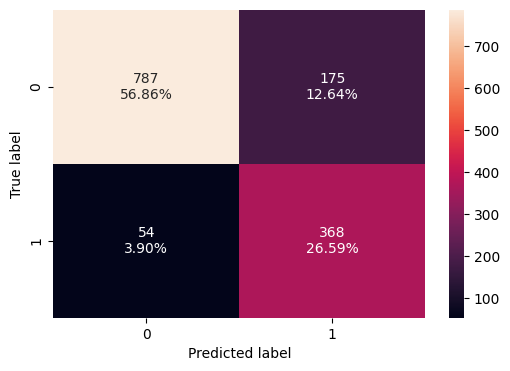

In [ ]:
confusion_matrix_statsmodels(best_model, X_test, y_test)

In [ ]:
decision_tree_post_performance_test = model_performance_classification_statsmodels(best_model, X_test, y_test)
decision_tree_post_performance_test

,Accuracy,Recall,Precision,F1
0,0.83454,0.87204,0.67772,0.76269


Observations: This model is showing higher recall at the expense of precision.

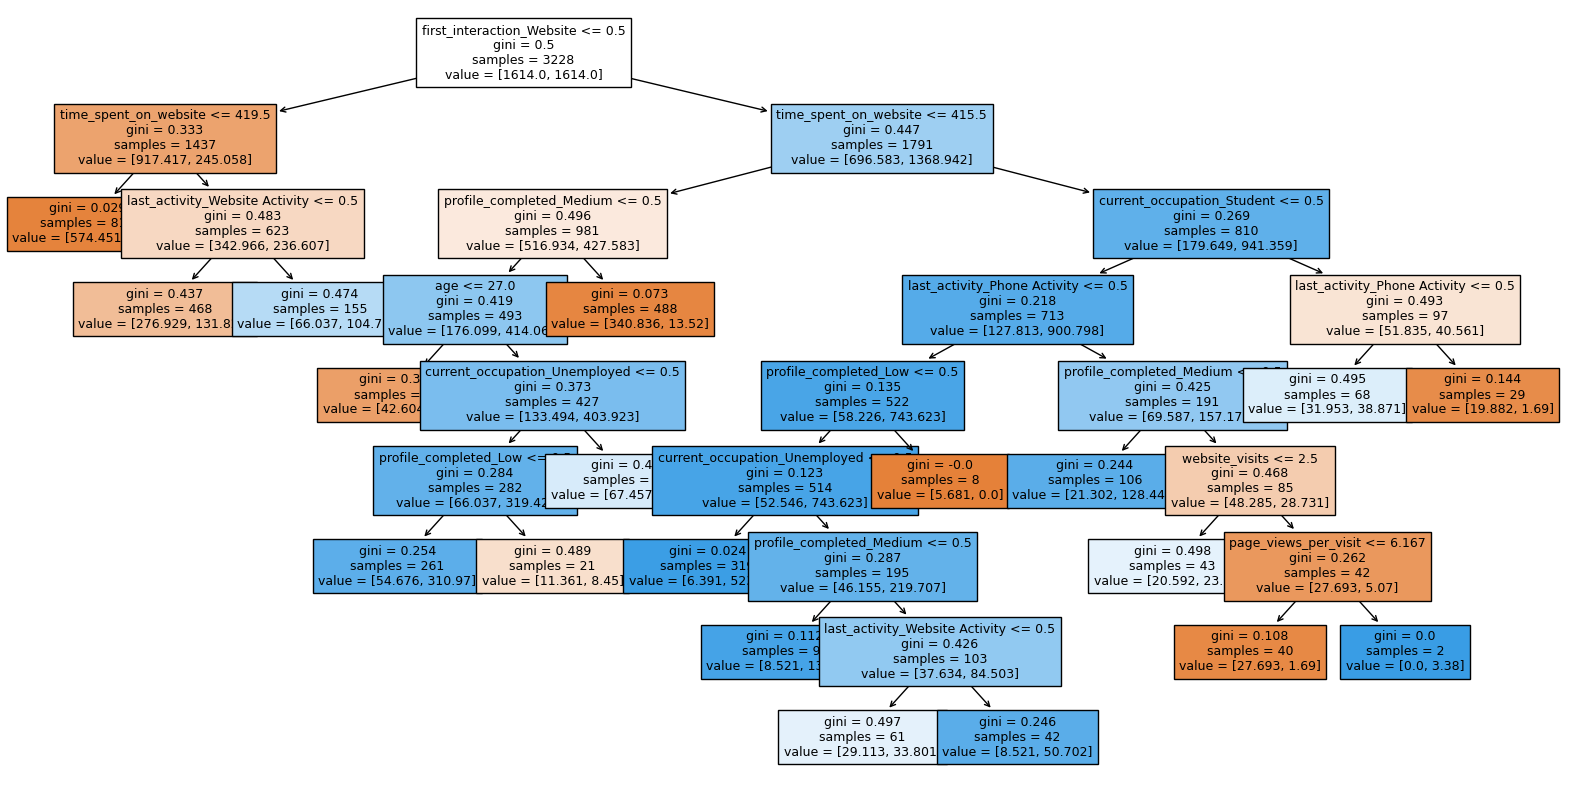

In [ ]:
plt.figure(figsize=(20, 10))

out = tree.plot_tree(
    best_model,
    feature_names=feature_names,
    filled=True,
    fontsize=9,
    node_ids=False,
    class_names=None,
)
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")
        arrow.set_linewidth(1)
plt.show()

In [ ]:
print(tree.export_text(best_model, feature_names=feature_names, show_weights=True))

|--- first_interaction_Website <= 0.50
|   |--- time_spent_on_website <= 419.50
|   |   |--- weights: [574.45, 8.45] class: 0
|   |--- time_spent_on_website >  419.50
|   |   |--- last_activity_Website Activity <= 0.50
|   |   |   |--- weights: [276.93, 131.82] class: 0
|   |   |--- last_activity_Website Activity >  0.50
|   |   |   |--- weights: [66.04, 104.78] class: 1
|--- first_interaction_Website >  0.50
|   |--- time_spent_on_website <= 415.50
|   |   |--- profile_completed_Medium <= 0.50
|   |   |   |--- age <= 27.00
|   |   |   |   |--- weights: [42.60, 10.14] class: 0
|   |   |   |--- age >  27.00
|   |   |   |   |--- current_occupation_Unemployed <= 0.50
|   |   |   |   |   |--- profile_completed_Low <= 0.50
|   |   |   |   |   |   |--- weights: [54.68, 310.97] class: 1
|   |   |   |   |   |--- profile_completed_Low >  0.50
|   |   |   |   |   |   |--- weights: [11.36, 8.45] class: 0
|   |   |   |   |--- current_occupation_Unemployed >  0.50
|   |   |   |   |   |--- weights: 

Observations: This tree is much more complex compared to the previous ones.

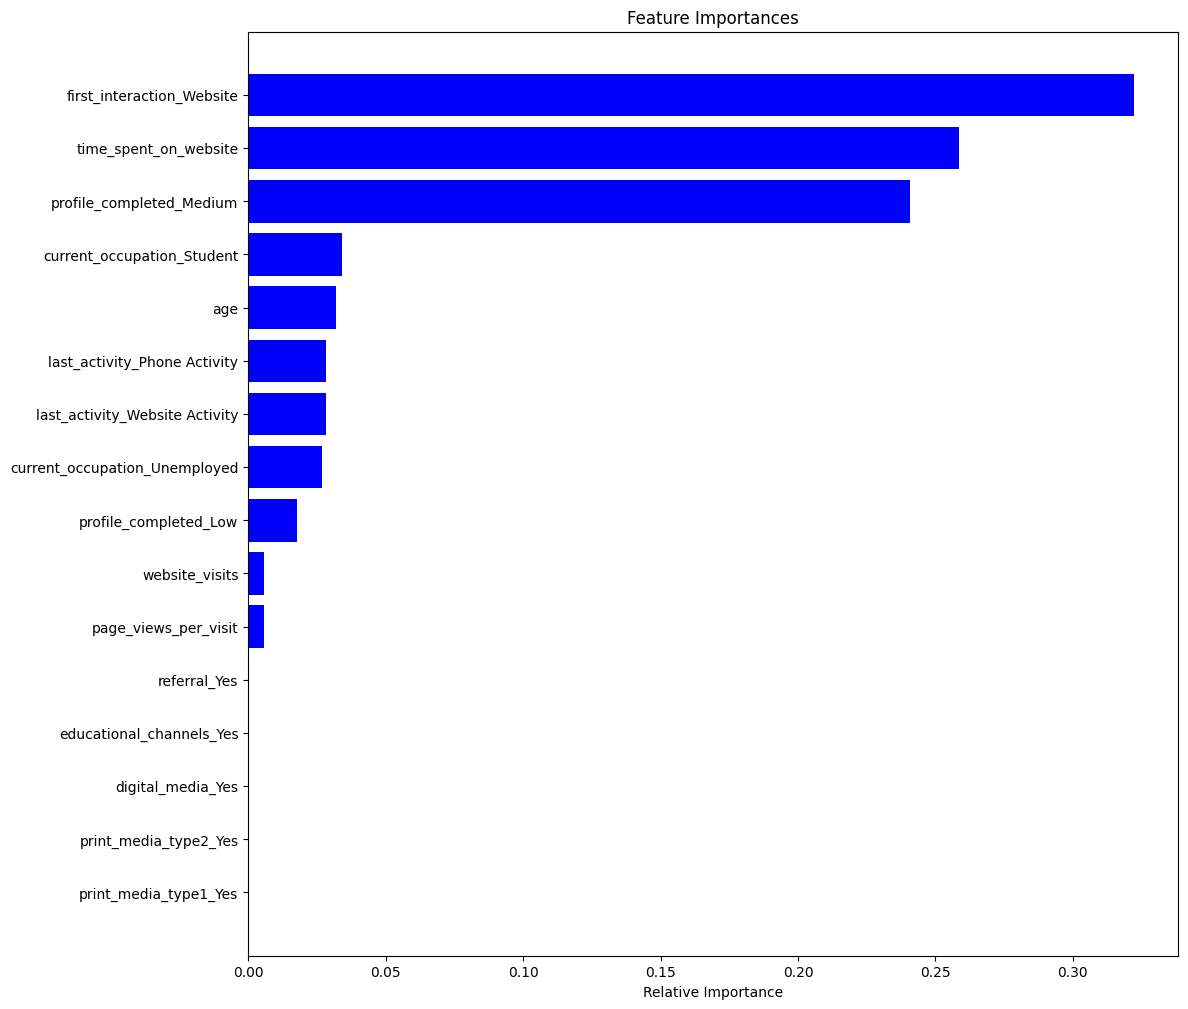

In [ ]:
importances = best_model.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12, 12))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="blue", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

Observations: The feature importance is about the same as the pre-pruned tree.

## Model Performance Comparison and Conclusions

### Training Set Performance

In [ ]:
# decision tree training performance comparison

models_train_performance = pd.concat(
    [
        decision_tree_model_train_performance.T,
        decision_tree_train_performance_pruned.T,
        decision_tree_post_performance_train.T,
    ],
    axis=1,
)
models_train_performance.columns = [
    "Decision Tree sklearn",
    "Decision Tree (Pre-Pruning)",
    "Decision Tree (Post-Pruning)",
]
print("Training performance comparison:")
models_train_performance

Training performance comparison:


,Decision Tree sklearn,Decision Tree (Pre-Pruning),Decision Tree (Post-Pruning)
Accuracy,1.00000,0.83550,0.83055
Recall,1.00000,0.85550,0.89110
Precision,1.00000,0.67521,0.65765
F1,1.00000,0.75473,0.75678


### Test Set Performance

In [ ]:
# decision tree test performance
models_test_performance = pd.concat(
    [
        decision_tree_model_test_performance.T,
        decision_tree_test_performance_pruned.T,
        decision_tree_post_performance_test.T,
        ],
    axis=1,
)
models_test_performance.columns = [
    "Decision Tree sklearn",
    "Decision Tree (Pre-Pruning)",
    "Decision Tree (Post-Pruning)",
]
print("Test performance comparison:")
models_test_performance

Test performance comparison:


,Decision Tree sklearn,Decision Tree (Pre-Pruning),Decision Tree (Post-Pruning)
Accuracy,0.81286,0.83526,0.83454
Recall,0.70142,0.84597,0.87204
Precision,0.68998,0.68654,0.67772
F1,0.69565,0.75796,0.76269


Observations:


*   The default decision tree model is overfitting the data.
*   The post-pruned tree has the highest recall score without sacrificing much accuracy.
* The post-pruned tree can best reduce false negatives.



## Actionable Insights and Recommendations



*   The post-pruned decision tree model performs the best on the dataset.
*   Important variables determining status in both models include first_interaction_Website and profile_completed_medium.
  * In the logistic regression model, current_occupation_Student, profile_completed_Low, and referral_yes are also important variables.
  * On the other hand, time_spent_on_website is an important variable in the decision tree model.
* Leads will generally not subscribe when their time spent on the website is low (less than 419.5), their last interaction was not via the website, and their profile has low completion.
* Leads will generally subscribe when their time spent of the website is high, their last interaction was via the website, and their profile has medium completion.
* The company can incentivize leads to complete greater percentages of their profiles by improving personalized content and adding benefits/features.
* The company should prioritize web traffic to convert more leads into subscribers.
* Increasing ways leads can interact with the website can increase the average amount of time they spend on the website, increasing the likelihood that they convert into subscribers.
* Unlike younger users, leads older than 27 are generally more likely to subscribe. Therefore, the company should use personalized advertizing to target older users.



